## SINKHOLE FORMATION RISK EVALUATION

In [1]:
# -------------------- Standard library --------------------
from collections import Counter
import io
import json
import logging
import math
import string
import zipfile

# -------------------- Third-party libraries --------------------
import numpy as np
import pandas as pd
from pandas.api.types import is_datetime64_any_dtype, is_period_dtype

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import seaborn as sns

import requests
from statsmodels.stats.outliers_influence import variance_inflation_factor

# scikit-learn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

# imbalanced-learn
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # sampler-capable pipeline

In [2]:
# since the .csv is large (>100 Mb) we download and read zip

# Google Drive file ID (from your original URL)
file_id = "1GF3PPqzu9aQ_E8PQJF1cy3TrDOMgJIe3"

# Direct download link for Google Drive
zip_url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Download and extract the ZIP file
response = requests.get(zip_url)
if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # Assume there's only one file in the ZIP
        file_name = z.namelist()[0]
        with z.open(file_name) as f:
            df = pd.read_csv(f)
else:
    print("Failed to download the ZIP file.")
df.head()
for col in df.columns:
    print(col)

/tmp/ipykernel_778/2368726369.py:16: DtypeWarning: Columns (16,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


date
well_no
precipitation_mm_eobs
temperature_C_eobs
actual_evapotranspiration_mm_gleam
potential_evapotranspiration_mm_gleam
site
local_ID
altitude_ m_asl
gw_level_m_asl
gw_level_ m_below_ground
site_id
site_name
country
observation_start_date
observation_end_date
well_installataion_date
depth_m
local_geo_index
standard_geo_index
regional_stage
aquifer_type
lithology
aquifer_top_m_from_land_surface
aquifer_bottom_m_from_land_surface
thickness
hydraulic_conductivity_md
drawdown
debit
comp_debit
address
WGS_lat
WGS_lon
land_surface_elevation_m
gw_level_m_from_land_surface
top_of_screen
bottom_of_screen
geometry
date_left
index_right
lat
lon
date_right
tws_mm_tavg_gldas
gws_mm_tavg_gldas
precipitation_mm_eobs_lag_30d
precipitation_mm_eobs_lag_60d
precipitation_mm_eobs_lag_90d
precipitation_mm_eobs_lag_180d
precipitation_mm_eobs_lag_270d
precipitation_mm_eobs_lag_360d
precipitation_mm_eobs_rollsum_60d
precipitation_mm_eobs_rollsum_90d
temperature_C_eobs_lag_30d
temperature_C_eobs_lag_60d

### Daily to monthly

Karst sinkholes occurence is monthly, therefore we need to agregate groundwater level data.

In [3]:
df_level = df[[
    'date',
    'well_no',
    'precipitation_mm_eobs',
    'temperature_C_eobs',
    'actual_evapotranspiration_mm_gleam',
    'potential_evapotranspiration_mm_gleam',
    'tws_mm_tavg_gldas',
    'gws_mm_tavg_gldas',
    'gw_level_m_asl_imputed'
]].copy()
# Ensure 'date' is datetime
df_level['date'] = pd.to_datetime(df_level['date'])

# Extract year-month string (e.g., "2025-08")
df_level['year_month'] = df_level['date'].dt.to_period('M').astype(str)

# Group by well_no and year_month
df_level_monthly = df_level.groupby(['well_no', 'year_month']).agg({
    'temperature_C_eobs': 'mean',
    'actual_evapotranspiration_mm_gleam': 'mean',
    'potential_evapotranspiration_mm_gleam': 'mean',
    'tws_mm_tavg_gldas': 'mean',
    'gws_mm_tavg_gldas': 'mean',
    'gw_level_m_asl_imputed': 'mean',
    'precipitation_mm_eobs': 'sum'
}).reset_index()
df_level_monthly.head()

,well_no,year_month,temperature_C_eobs,actual_evapotranspiration_mm_gleam,potential_evapotranspiration_mm_gleam,tws_mm_tavg_gldas,gws_mm_tavg_gldas,gw_level_m_asl_imputed,precipitation_mm_eobs
0,LT_220,2003-01,-5.495484,0.215376,0.231230,NaN,NaN,NaN,28.500000
1,LT_220,2003-02,-5.856071,0.097290,0.097290,2183.445354,1797.124571,NaN,15.700000
2,LT_220,2003-03,0.411613,0.693402,1.182610,2170.960177,1822.416445,NaN,5.100000
3,LT_220,2003-04,4.797667,1.452514,2.243388,2169.173690,1842.527880,NaN,45.700001
4,LT_220,2003-05,13.223871,2.173896,3.265145,2158.518623,1834.274361,NaN,64.000002


In [4]:
# read sinkhole data
sheet_url = "https://docs.google.com/spreadsheets/d/160ntRKCTC3CzqCW8kwEuQ6fKoR7KPXtC/edit?usp=drive_link&ouid=110322647464513529230&rtpof=true&sd=true"
file_id = sheet_url.split("/d/")[1].split("/")[0]
sheet_name = "Sheet1"
csv_url = f"https://docs.google.com/spreadsheets/d/{file_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df_sink = pd.read_csv(csv_url)
df_sink.head()

,id,type,description,address,region,Y,X,lat,lon,date_inserted,date_event
0,983,Smegduobė,NaN,"Panevėžio apskr., Biržų r. sav., Pabiržės sen....",Šiaurės Lietuvos karstinis rajonas,538184,6225765,56.164152,24.614729,2015-05-07,2011-04-01
1,1066,Smegduobė,"Pievoje, banguotos lygumos daubos šlaite","Panevėžio apskr., Biržų r. sav., Širvėnos sen....",Šiaurės Lietuvos karstinis rajonas,543725,6228815,56.191072,24.704429,2016-04-05,1990-04-01
2,1095,Smegduobė,"Prie pastato Nr.10, darželio „Liepaitė“ vidini...","Panevėžio apskr., Pasvalio r. sav., Pasvalio m...",Šiaurės Lietuvos karstinis rajonas,525748,6214420,56.063076,24.413434,2016-11-26,2016-11-25
3,1098,Smegduobė,Keturių smegduobių grupėje. Pirma. Miške,"Panevėžio apskr., Biržų r. sav., Širvėnos sen....",Šiaurės Lietuvos karstinis rajonas,542303,6230997,56.210799,24.681869,2016-05-05,2016-04-01
4,1100,Smegduobė,Keturių smegduobių grupėje trečia. Miško pakra...,"Panevėžio apskr., Biržų r. sav., Širvėnos sen....",Šiaurės Lietuvos karstinis rajonas,542300,6230998,56.210809,24.681821,2016-05-06,2016-04-01


### Sinkhole timeseries plots

Analyzing sinkhole occurrences over time is essential to understand their temporal patterns and identify periods of increased risk. By examining the monthly distribution of sinkhole events, we can uncover trends and seasonal variations that may inform prevention and mitigation strategies. This analysis focuses on sinkhole data from 2003 onwards, providing insights into how these events fluctuate both across specific months in each year and cumulatively by calendar month.

/tmp/ipykernel_778/593236697.py:99: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


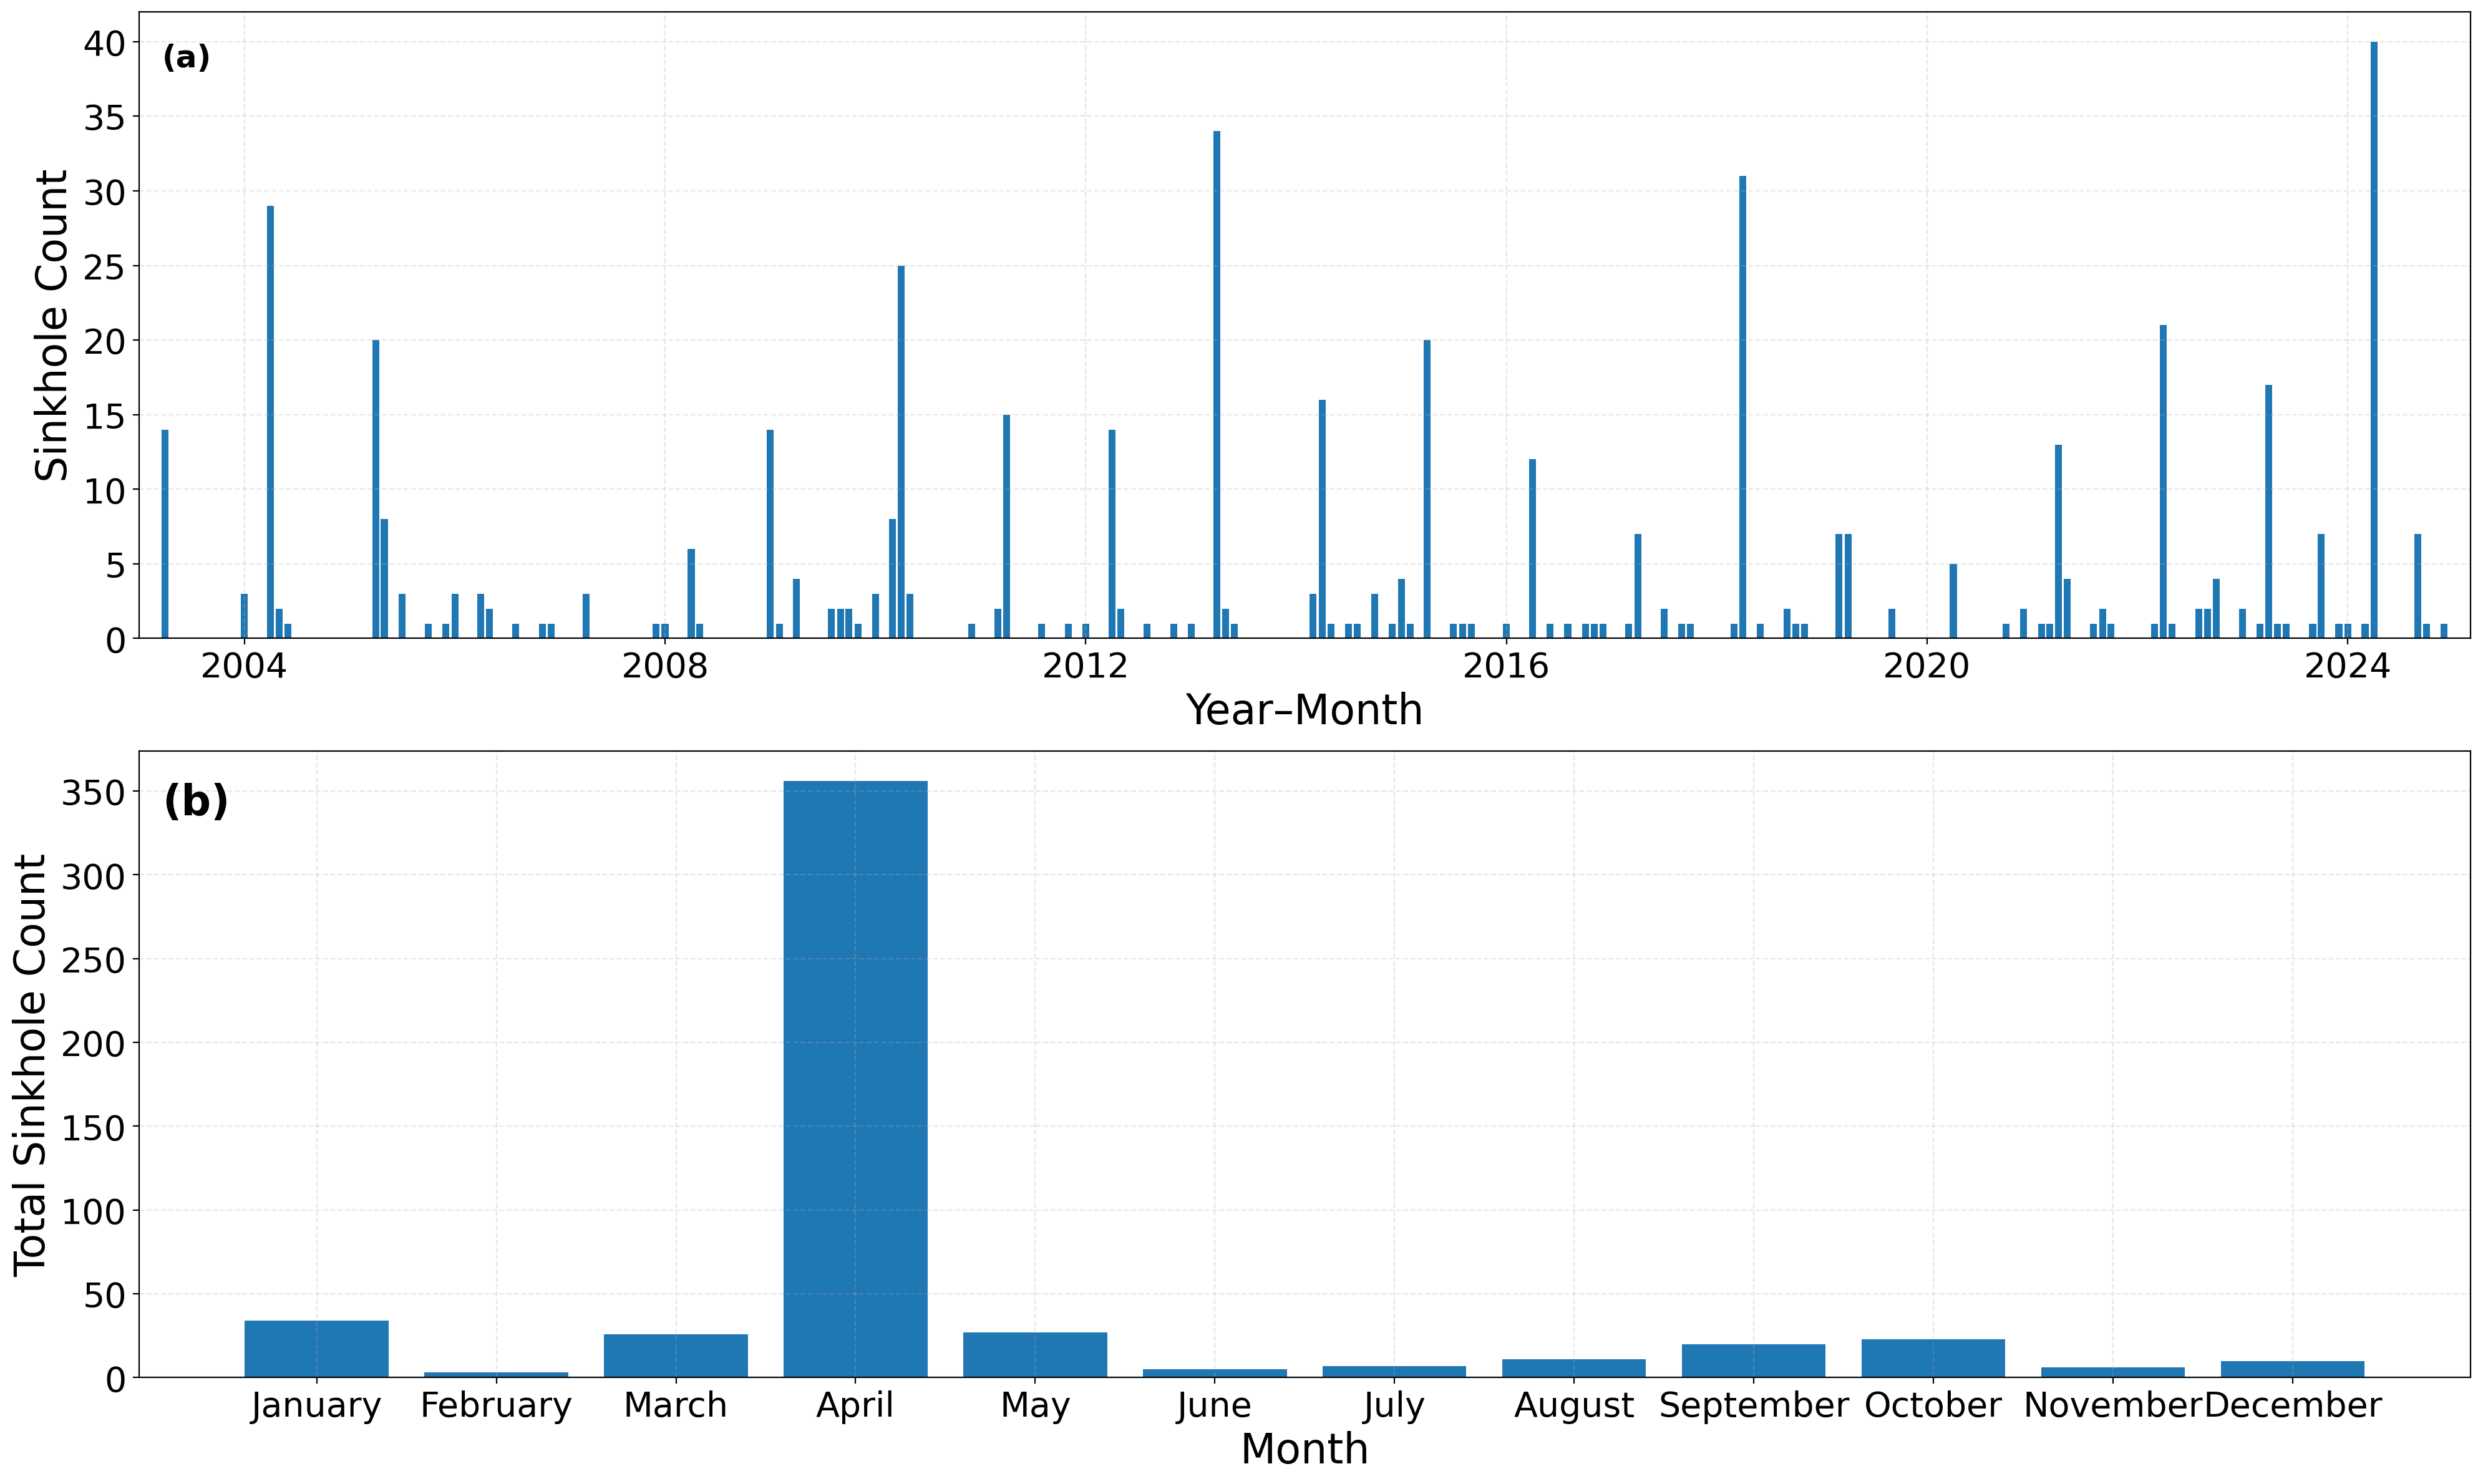

In [5]:
# -------------------------
# Step 1: Clean & prepare
# -------------------------
df_sink_plot = df_sink[df_sink['date_event'].notna()].copy()
df_sink_plot['date_event'] = pd.to_datetime(df_sink_plot['date_event'])
# Keep a true monthly Period for grouping, then convert to Timestamp for plotting
df_sink_plot['year_month'] = df_sink_plot['date_event'].dt.to_period('M')

# -------------------------
# Step 2: Group monthly
# -------------------------
df_sink_plot_count_monthly = (
    df_sink_plot
    .groupby('year_month')
    .size()
    .rename('sink_count')
    .reset_index()
)

# Chronological order is better for a time series
df_sink_plot_count_monthly = df_sink_plot_count_monthly.sort_values('year_month')

# -------------------------
# Step 3: Filter from 2003+
# -------------------------
df_sink_plot_count_monthly = df_sink_plot_count_monthly[df_sink_plot_count_monthly['year_month'] >= pd.Period('2003-01', freq='M')]

# Convert Period -> Timestamp (month start) for plotting on a date axis
df_sink_plot_count_monthly['ym_ts'] = df_sink_plot_count_monthly['year_month'].dt.to_timestamp()

# -------------------------
# Step 4: Calendar-month totals (Jan–Dec)
# -------------------------
df_sink_plot_count_monthly['month_name'] = df_sink_plot_count_monthly['ym_ts'].dt.month_name()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_total = (
    df_sink_plot_count_monthly
    .groupby('month_name')['sink_count']
    .sum()
    .reindex(month_order)           # ensure calendar order
    .fillna(0)
)

# -------------------------
# Styling for visibility
# -------------------------
plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 200,
    'savefig.dpi': 600,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 1,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

# -------------------------
# Step 5: Plot (two subplots)
# -------------------------
fig, axs = plt.subplots(2, 1, figsize=(20, 12), constrained_layout=True)
fig.patch.set_facecolor('white')

# (a) Monthly sink count time series
ax = axs[0]
ax.bar(
    df_sink_plot_count_monthly['ym_ts'],
    df_sink_plot_count_monthly['sink_count'],
    width=pd.Timedelta(days=24)    # ~1 month bar width for readability
)
# ax.set_title('Monthly Sinkhole Count (2003–present)')
ax.set_xlabel('Year–Month', fontsize=24)
ax.set_ylabel('Sinkhole Count', fontsize=24)

# Cleaner date axis
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.margins(x=0.01)
ax.tick_params(axis='x', rotation=0)
ax.text(0.01, 0.95, '(a)', transform=ax.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')

# (b) Total occurrences by calendar month
ax2 = axs[1]
ax2.bar(monthly_total.index, monthly_total.values)
# ax2.set_title('Total Sinkhole Occurrences by Calendar Month (All Years ≥ 2003)')
ax2.set_xlabel('Month', fontsize=24)
ax2.set_ylabel('Total Sinkhole Count', fontsize=24)
ax2.tick_params(axis='x', rotation=0)
ax2.text(0.01, 0.95, '(b)', transform=ax2.transAxes, fontsize=24, fontweight='bold', va='top', ha='left')

# Finalize layout and save
plt.tight_layout()
plt.savefig('sinkhole_analysis.jpeg', dpi=600)
plt.show()

### Join tables

Joining the sinkhole count data with monthly level data is crucial for comprehensive analysis, as it allows us to explore potential relationships between sinkhole occurrences and other monthly variables. By combining these datasets based on the common year_month field, we create a unified view that integrates both environmental or contextual factors and sinkhole activity over time.

In [6]:
def to_month_period(s):
    """Coerce a Series/Index to monthly Period[M] without deprecated checks."""
    dtype = getattr(s, "dtype", None)

    if isinstance(dtype, pd.PeriodDtype):
        # Already Period -> just enforce monthly freq
        return s.astype("period[M]")
    elif is_datetime64_any_dtype(s):
        # Datetime -> monthly Period
        return s.dt.to_period("M") if hasattr(s, "dt") else s.to_period("M")
    else:
        # Strings/objects -> parse to datetime, then to Period
        s_dt = pd.to_datetime(s, errors="coerce")
        return s_dt.dt.to_period("M") if hasattr(s_dt, "dt") else s_dt.to_period("M")


# --- Build monthly counts with a true monthly Period key ---
df_sink = df_sink[df_sink['date_event'].notna()].copy()
df_sink['date_event'] = pd.to_datetime(df_sink['date_event'])
df_sink['year_month'] = df_sink['date_event'].dt.to_period('M')

df_sink_count_monthly = (
    df_sink.groupby('year_month')
           .size()
           .rename('sink_count')
           .reset_index()
)

# --- Make BOTH sides monthly Period[M] (no to_datetime on Period!) ---
df_level_monthly['year_month']       = to_month_period(df_level_monthly['year_month'])
df_sink_count_monthly['year_month']  = to_month_period(df_sink_count_monthly['year_month'])

# --- Merge (fix the name if you had a typo earlier) ---
df_work = pd.merge(
    df_level_monthly,
    df_sink_count_monthly,  # not df_sink_plot_count_monthly
    on='year_month',
    how='left'
)

# --- Post-merge columns ---
df_work['sink_count']     = df_work['sink_count'].fillna(0).astype(int)

# Period accessors now work
df_work['year']           = df_work['year_month'].dt.year
df_work['month']          = df_work['year_month'].dt.month
df_work['month_name']     = df_work['year_month'].dt.to_timestamp().dt.month_name()

# Keep a string label for display, but don’t overwrite the Period key
df_work['year_month_str'] = df_work['year_month'].astype(str)  # 'YYYY-MM'

# If you also need a datetime for plotting (month start):
df_work['year_month_ts']  = df_work['year_month'].dt.to_timestamp()

df_work.head()

,well_no,year_month,temperature_C_eobs,actual_evapotranspiration_mm_gleam,potential_evapotranspiration_mm_gleam,tws_mm_tavg_gldas,gws_mm_tavg_gldas,gw_level_m_asl_imputed,precipitation_mm_eobs,sink_count,year,month,month_name,year_month_str,year_month_ts
0,LT_220,2003-01,-5.495484,0.215376,0.231230,NaN,NaN,NaN,28.500000,0,2003,1,January,2003-01,2003-01-01
1,LT_220,2003-02,-5.856071,0.097290,0.097290,2183.445354,1797.124571,NaN,15.700000,0,2003,2,February,2003-02,2003-02-01
2,LT_220,2003-03,0.411613,0.693402,1.182610,2170.960177,1822.416445,NaN,5.100000,0,2003,3,March,2003-03,2003-03-01
3,LT_220,2003-04,4.797667,1.452514,2.243388,2169.173690,1842.527880,NaN,45.700001,14,2003,4,April,2003-04,2003-04-01
4,LT_220,2003-05,13.223871,2.173896,3.265145,2158.518623,1834.274361,NaN,64.000002,0,2003,5,May,2003-05,2003-05-01


### THRESHOLD HIGH-LOW RISK SINKHOLE FORMATION
Using a calculated threshold instead of guessing ensures that the classification of high-risk and low-risk periods is based on objective, data-driven criteria.

Average monthly sink_count: 1.89
Median monthly sink_count: 0.00
IQR-based High Risk Threshold: 2.50
Z-Score-based High Risk Threshold: 11.86
90th Percentile Threshold: 4.00
K-Means Clustering: Cluster centers = [ 0.76793249 19.66666667]


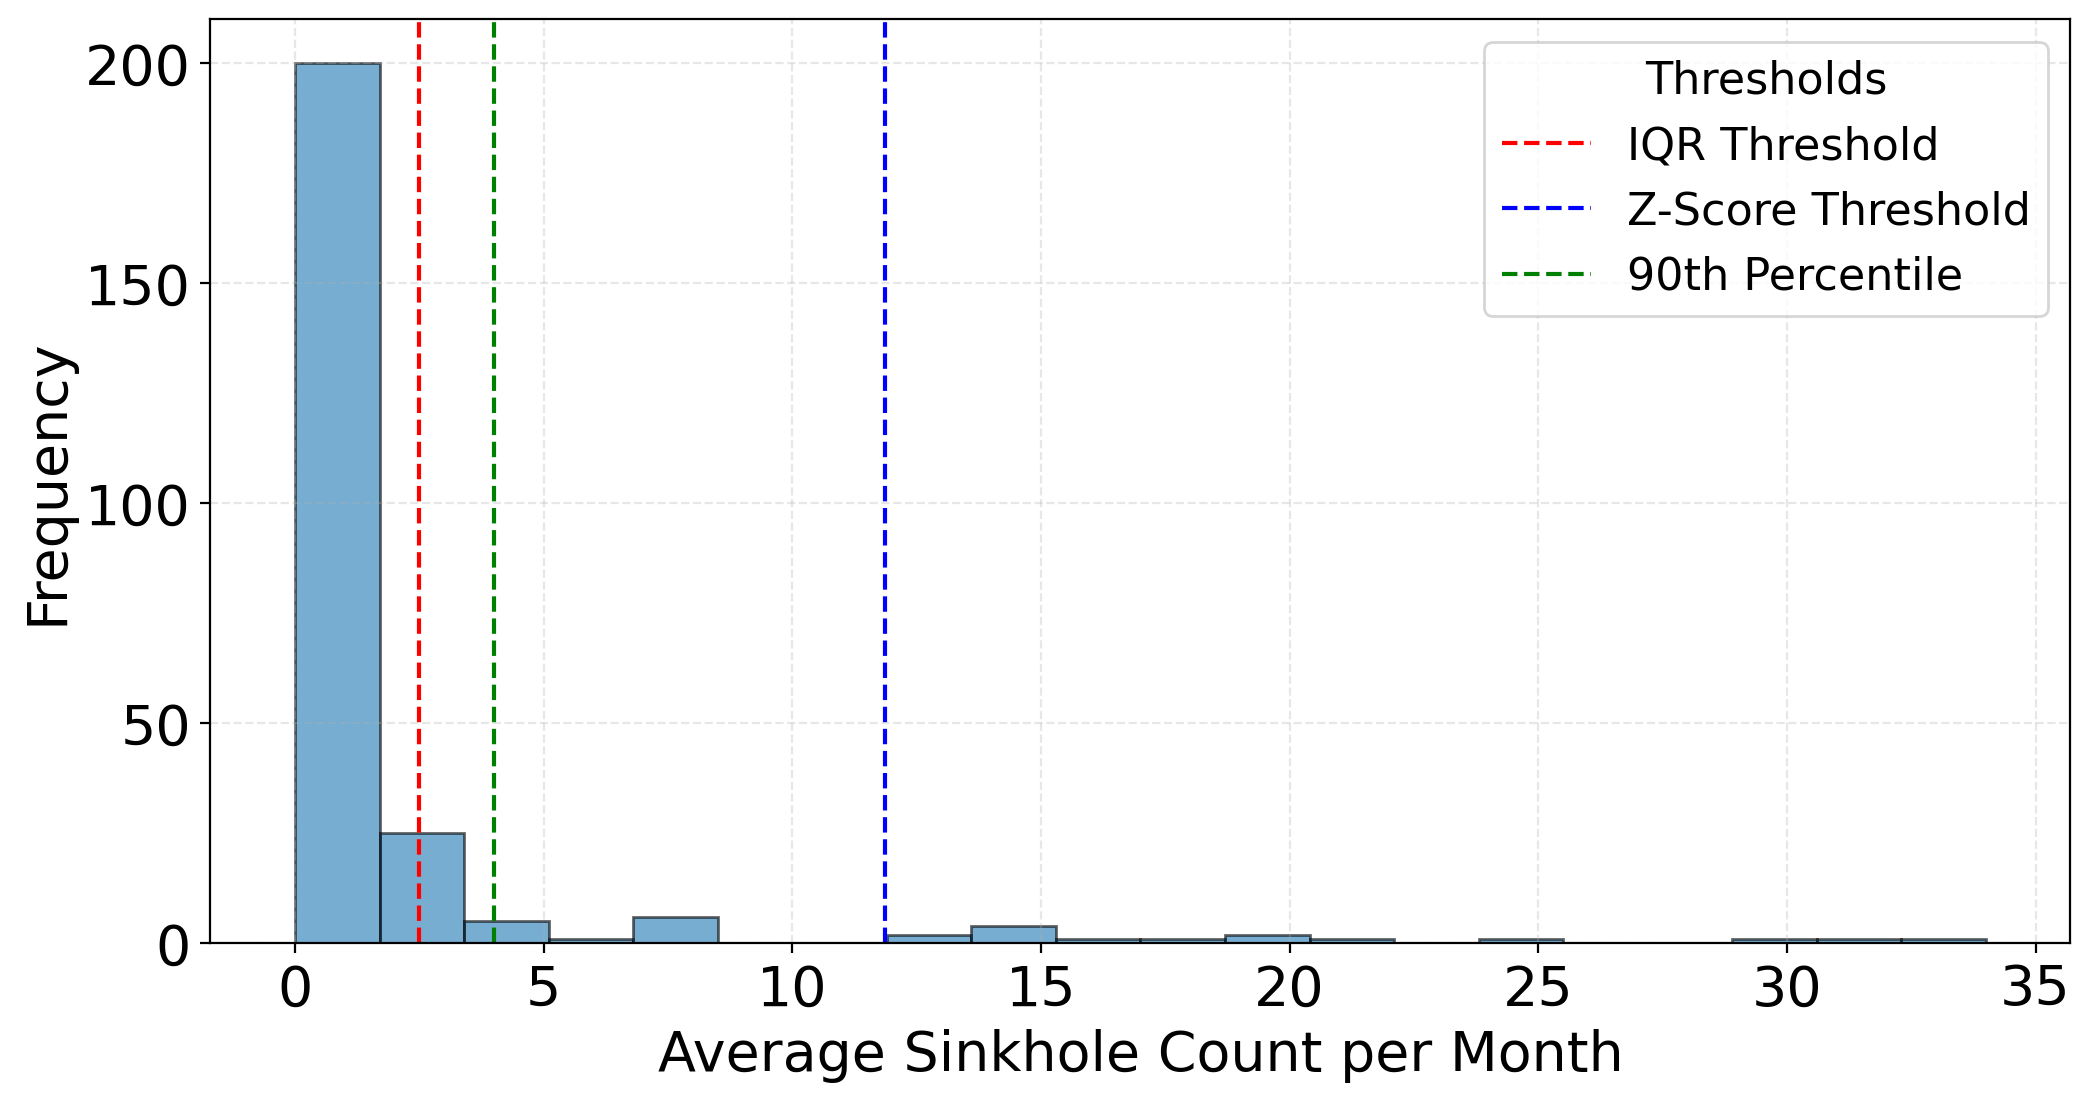

In [7]:
# Filter data
filtered_df = df_work[df_work['well_no'] == 'LT_220']

# Group by year_month and calculate mean sink_count per month
monthly_avg = filtered_df.groupby('year_month')['sink_count'].mean()

# Overall average and median of monthly averages
overall_avg = monthly_avg.mean()
overall_median = monthly_avg.median()

print(f"Average monthly sink_count: {overall_avg:.2f}")
print(f"Median monthly sink_count: {overall_median:.2f}")

# --- Threshold Evaluation ---

# IQR Method
Q1 = monthly_avg.quantile(0.25)
Q3 = monthly_avg.quantile(0.75)
IQR = Q3 - Q1
iqr_threshold = Q3 + 1.5 * IQR

# Z-Score Method
mean = monthly_avg.mean()
std = monthly_avg.std()
zscore_threshold = mean + 2 * std

# Percentile Method (90th percentile)
percentile_threshold = monthly_avg.quantile(0.90)

# K-Means Clustering (2 clusters: low and high risk)
kmeans = KMeans(n_clusters=2, random_state=0)
monthly_avg_reshaped = monthly_avg.values.reshape(-1, 1)
kmeans.fit(monthly_avg_reshaped)
labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_.flatten()

# Identify which cluster is high risk
high_risk_cluster = labels[np.argmax(cluster_centers)]
monthly_avg_clustered = pd.DataFrame({
    'year_month': monthly_avg.index,
    'avg_sink_count': monthly_avg.values,
    'risk_cluster': labels
})
monthly_avg_clustered['risk_label'] = monthly_avg_clustered['risk_cluster'].apply(
    lambda x: 'High Risk' if x == high_risk_cluster else 'Low Risk'
)

# --- Print thresholds ---
print(f"IQR-based High Risk Threshold: {iqr_threshold:.2f}")
print(f"Z-Score-based High Risk Threshold: {zscore_threshold:.2f}")
print(f"90th Percentile Threshold: {percentile_threshold:.2f}")
print("K-Means Clustering: Cluster centers =", cluster_centers)

# --- Optional: Visualization ---
plt.figure(figsize=(12, 6))
plt.hist(monthly_avg, bins=20, edgecolor='black', alpha=0.6)
plt.axvline(iqr_threshold, color='red', linestyle='--', label='IQR Threshold')
plt.axvline(zscore_threshold, color='blue', linestyle='--', label='Z-Score Threshold')
plt.axvline(percentile_threshold, color='green', linestyle='--', label='90th Percentile')
plt.xlabel('Average Sinkhole Count per Month')
plt.ylabel('Frequency')
plt.legend(fontsize=16, title="Thresholds", title_fontsize=16)
plt.grid(True)
plt.savefig("risk_threshold_estimation.jpeg", dpi=600)
plt.show()

Choosing a threshold of 3 balances sensitivity and specificity by being slightly above the IQR-based threshold (2.5) but below the 90th percentile (4). This makes the threshold effective at capturing months with notably elevated sink_count, while avoiding excessive false positives from normal variability.

### Engineer Features

1. Lag and Rolling Features
Purpose: To capture temporal dependencies and trends in groundwater and related climate variables.

Why: Groundwater levels and climate variables (temperature, precipitation, evapotranspiration) often show delayed effects. For example, rainfall this month may influence groundwater levels in the following months.

Lag Features: Past values (1 to 3 months back) provide information about recent history that can affect current groundwater status.

Rolling Features: Rolling means or sums smooth out short-term fluctuations and reveal underlying trends or accumulations over a moving window (3 months). The 1-month shift avoids data leakage by only using past data.

2. Seasonality Encoding (Sine/Cosine Transformations)
Purpose: To capture seasonal patterns and cyclical effects throughout the year.

Why: Groundwater levels and evapotranspiration vary seasonally due to changes in climate and hydrological cycles (e.g., wet/dry seasons).

Method: Represent month as a circular variable using sine and cosine transforms, allowing the model to learn seasonal cycles without artificial discontinuities between December and January.

Seasonal Phase and Modulation: Combining groundwater or evapotranspiration data with seasonal phase helps to explicitly model how these variables fluctuate within a year.

3. Groundwater Seasonality-Adjusted Features
Groundwater Level Above/Below Average: Indicates if the current level is higher or lower than the well’s average, helping to detect anomalies.

Near 6-Month Peak: Flags periods when groundwater is near a local peak, useful to detect seasonal maxima or drought recovery.

One-month Delta: Captures short-term rate of change, indicating rising or falling trends.

3-month Trend: A smoothed rate of change to detect medium-term trends.

Seasonal Modulation: Interactions of groundwater with seasonal cycles to reflect how groundwater behaves differently across seasons.

4. Evapotranspiration Ratio
Purpose: To measure the efficiency or stress of evapotranspiration by comparing actual vs potential values.

Why: This ratio helps identify water stress conditions — if actual evapotranspiration is much less than potential, it could indicate drought stress affecting groundwater recharge.

5. Freezing Conditions and Consecutive Freezing Days
Purpose: To capture the effects of freezing temperatures on groundwater recharge and soil moisture.

Why: Frozen ground can reduce infiltration and alter groundwater dynamics. Consecutive freezing days can exacerbate this effect.

Consecutive Freezing Count: Tracks persistence of freezing conditions, which may have cumulative hydrological impacts.

6. Groundwater Spike Features
Daily Difference: Measures sudden changes in groundwater level.

3-month Cumulative Increase: Aggregates recent changes to capture sustained rises or declines.

Spike Flag and Count: Identifies and counts sudden groundwater level increases (>0.5m), potentially indicating rapid recharge events or measurement anomalies.

7. Sink Count to Risk Mapping
Purpose: To categorize wells based on sinkhole occurrences.

Why: Sinkhole counts reflect risk to groundwater infrastructure and surface stability.

Thresholding: Creates a binary risk level (low vs high) for easier classification and interpretation, helping to flag wells at risk for targeted management.

In [8]:
threshold = 4

# === Lag and Rolling Feature Configuration ===
lag_features = [
    'gw_level_m_asl_imputed',
    'temperature_C_eobs',
    'precipitation_mm_eobs',
    'actual_evapotranspiration_mm_gleam',
    'potential_evapotranspiration_mm_gleam',
    'tws_mm_tavg_gldas',
    'gws_mm_tavg_gldas',
]

n_lags = 3           # Number of lag months
rolling_window = 3   # Rolling window size

rolling_mean_features = ['gw_level_m_asl_imputed', 'temperature_C_eobs', 'tws_mm_tavg_gldas', 'gws_mm_tavg_gldas',]
rolling_sum_features = ['precipitation_mm_eobs', 'actual_evapotranspiration_mm_gleam', 'potential_evapotranspiration_mm_gleam']

# === Generate Lag and Rolling Features ===
for feature in lag_features:
    # Lag features (1 to n_lags months back)
    for lag in range(1, n_lags + 1):
        df_work[f'{feature}_lag_{lag}'] = df_work.groupby('well_no')[feature].shift(lag)

    # Rolling Mean or Sum Features (with 1-month shift to avoid data leakage)
    if feature in rolling_mean_features:
        df_work[f'{feature}_roll_mean_{rolling_window}'] = (
            df_work.groupby('well_no')[feature]
            .transform(lambda x: x.shift(1).rolling(window=rolling_window, min_periods=1).mean())
        )
    elif feature in rolling_sum_features:
        df_work[f'{feature}_roll_sum_{rolling_window}'] = (
            df_work.groupby('well_no')[feature]
            .transform(lambda x: x.shift(1).rolling(window=rolling_window, min_periods=1).sum())
        )

# === Encode Seasonality with Sine/Cosine Transformation ===
df_work['month_sin'] = np.sin(2 * np.pi * df_work['month'] / 12)
df_work['month_cos'] = np.cos(2 * np.pi * df_work['month'] / 12)

# Seasonal phase angle in radians
df_work['seasonal_phase'] = np.arctan2(df_work['month_sin'], df_work['month_cos'])

# Seasonal modulation of evapotranspiration (optional)
df_work['seasonal_evapo_effect'] = df_work['actual_evapotranspiration_mm_gleam'] * df_work['seasonal_phase']

# === Groundwater Seasonality-Adjusted Features ===

# Groundwater level above/below well average
df_work['gw_level_above_avg'] = df_work.groupby('well_no')['gw_level_m_asl_imputed'].transform(
    lambda x: x > x.mean()
).astype(int)

# Whether GW level is near recent 6-month peak (centered)
df_work['gw_level_near_peak'] = df_work.groupby('well_no')['gw_level_m_asl_imputed'].transform(
    lambda x: x.rolling(window=6, center=True).max() == x
).astype(int)

# One-month delta (rate of change)
df_work['gw_level_delta_1'] = df_work['gw_level_m_asl_imputed'] - df_work['gw_level_m_asl_imputed_lag_1']

# Rolling 3-month trend (slope-like)
df_work['gw_level_trend_3'] = df_work.groupby('well_no')['gw_level_m_asl_imputed'].transform(
    lambda x: x.diff().rolling(3).mean()
)

# Seasonal modulation: Multiply GW level by seasonal components to capture cyclical effects
df_work['gw_level_seasonal_sin'] = df_work['gw_level_m_asl_imputed'] * df_work['month_sin']
df_work['gw_level_seasonal_cos'] = df_work['gw_level_m_asl_imputed'] * df_work['month_cos']
df_work['gw_level_seasonal_phase'] = df_work['gw_level_m_asl_imputed'] * df_work['seasonal_phase']

# === Evapotranspiration Ratio ===
df_work['evapo_ratio'] = df_work['actual_evapotranspiration_mm_gleam'] / (
    df_work['potential_evapotranspiration_mm_gleam'] + 1e-5
)

# === Freezing Conditions Analysis ===
df_work['is_freezing'] = (df_work['temperature_C_eobs'] <= 0).astype(int)

def compute_consecutive_freezing(series):
    max_consec = []
    count = 0
    for val in series:
        if val == 1:
            count += 1
        else:
            count = 0
        max_consec.append(count)
    return max_consec

df_work['consec_freezing'] = df_work.groupby('well_no')['is_freezing'].transform(compute_consecutive_freezing)

# === Groundwater Spike Features ===

# Daily diff
df_work['gw_level_diff'] = df_work['gw_level_m_asl_imputed'].diff()

# 3-month cumulative increase
df_work['gw_level_rolling_increase'] = df_work['gw_level_diff'].rolling(window=3).sum()

# Flag if sudden spike > 0.5 meters
df_work['gw_level_spike'] = (df_work['gw_level_diff'] > 0.5).astype(int)

# Count of such spikes over past 6 months
df_work['gw_spike_count_6m'] = df_work['gw_level_spike'].rolling(window=6).sum()

# === Sink Count to Risk Mapping ===

# Categorize based on sink count
bins = [0, threshold, float('inf')]
categories = [0, 1]

df_work['sink_category'] = pd.cut(
    df_work['sink_count'],
    bins=bins,
    labels=categories,
    right=True,
    include_lowest=True
)

# Map to human-readable risk labels
risk_map = {
    0: "Low risk",
    1: "High risk",
}
df_work['risk_level'] = df_work['sink_category'].astype(int).map(risk_map)

### SCATTERS OF LEVEL VS GWS and TWS

Correlation analysis helps us:

Identify Strong Predictors: Features with high absolute correlation to the target are often the most informative for prediction.

Feature Selection: It guides the choice of which variables to include or exclude, potentially improving model performance and reducing complexity.

Detect Redundancy: Highly correlated features may provide overlapping information, suggesting opportunities for dimensionality reduction.

Gain Domain Insights: Understanding these relationships helps validate assumptions and uncover underlying processes influencing sinkhole occurrences.

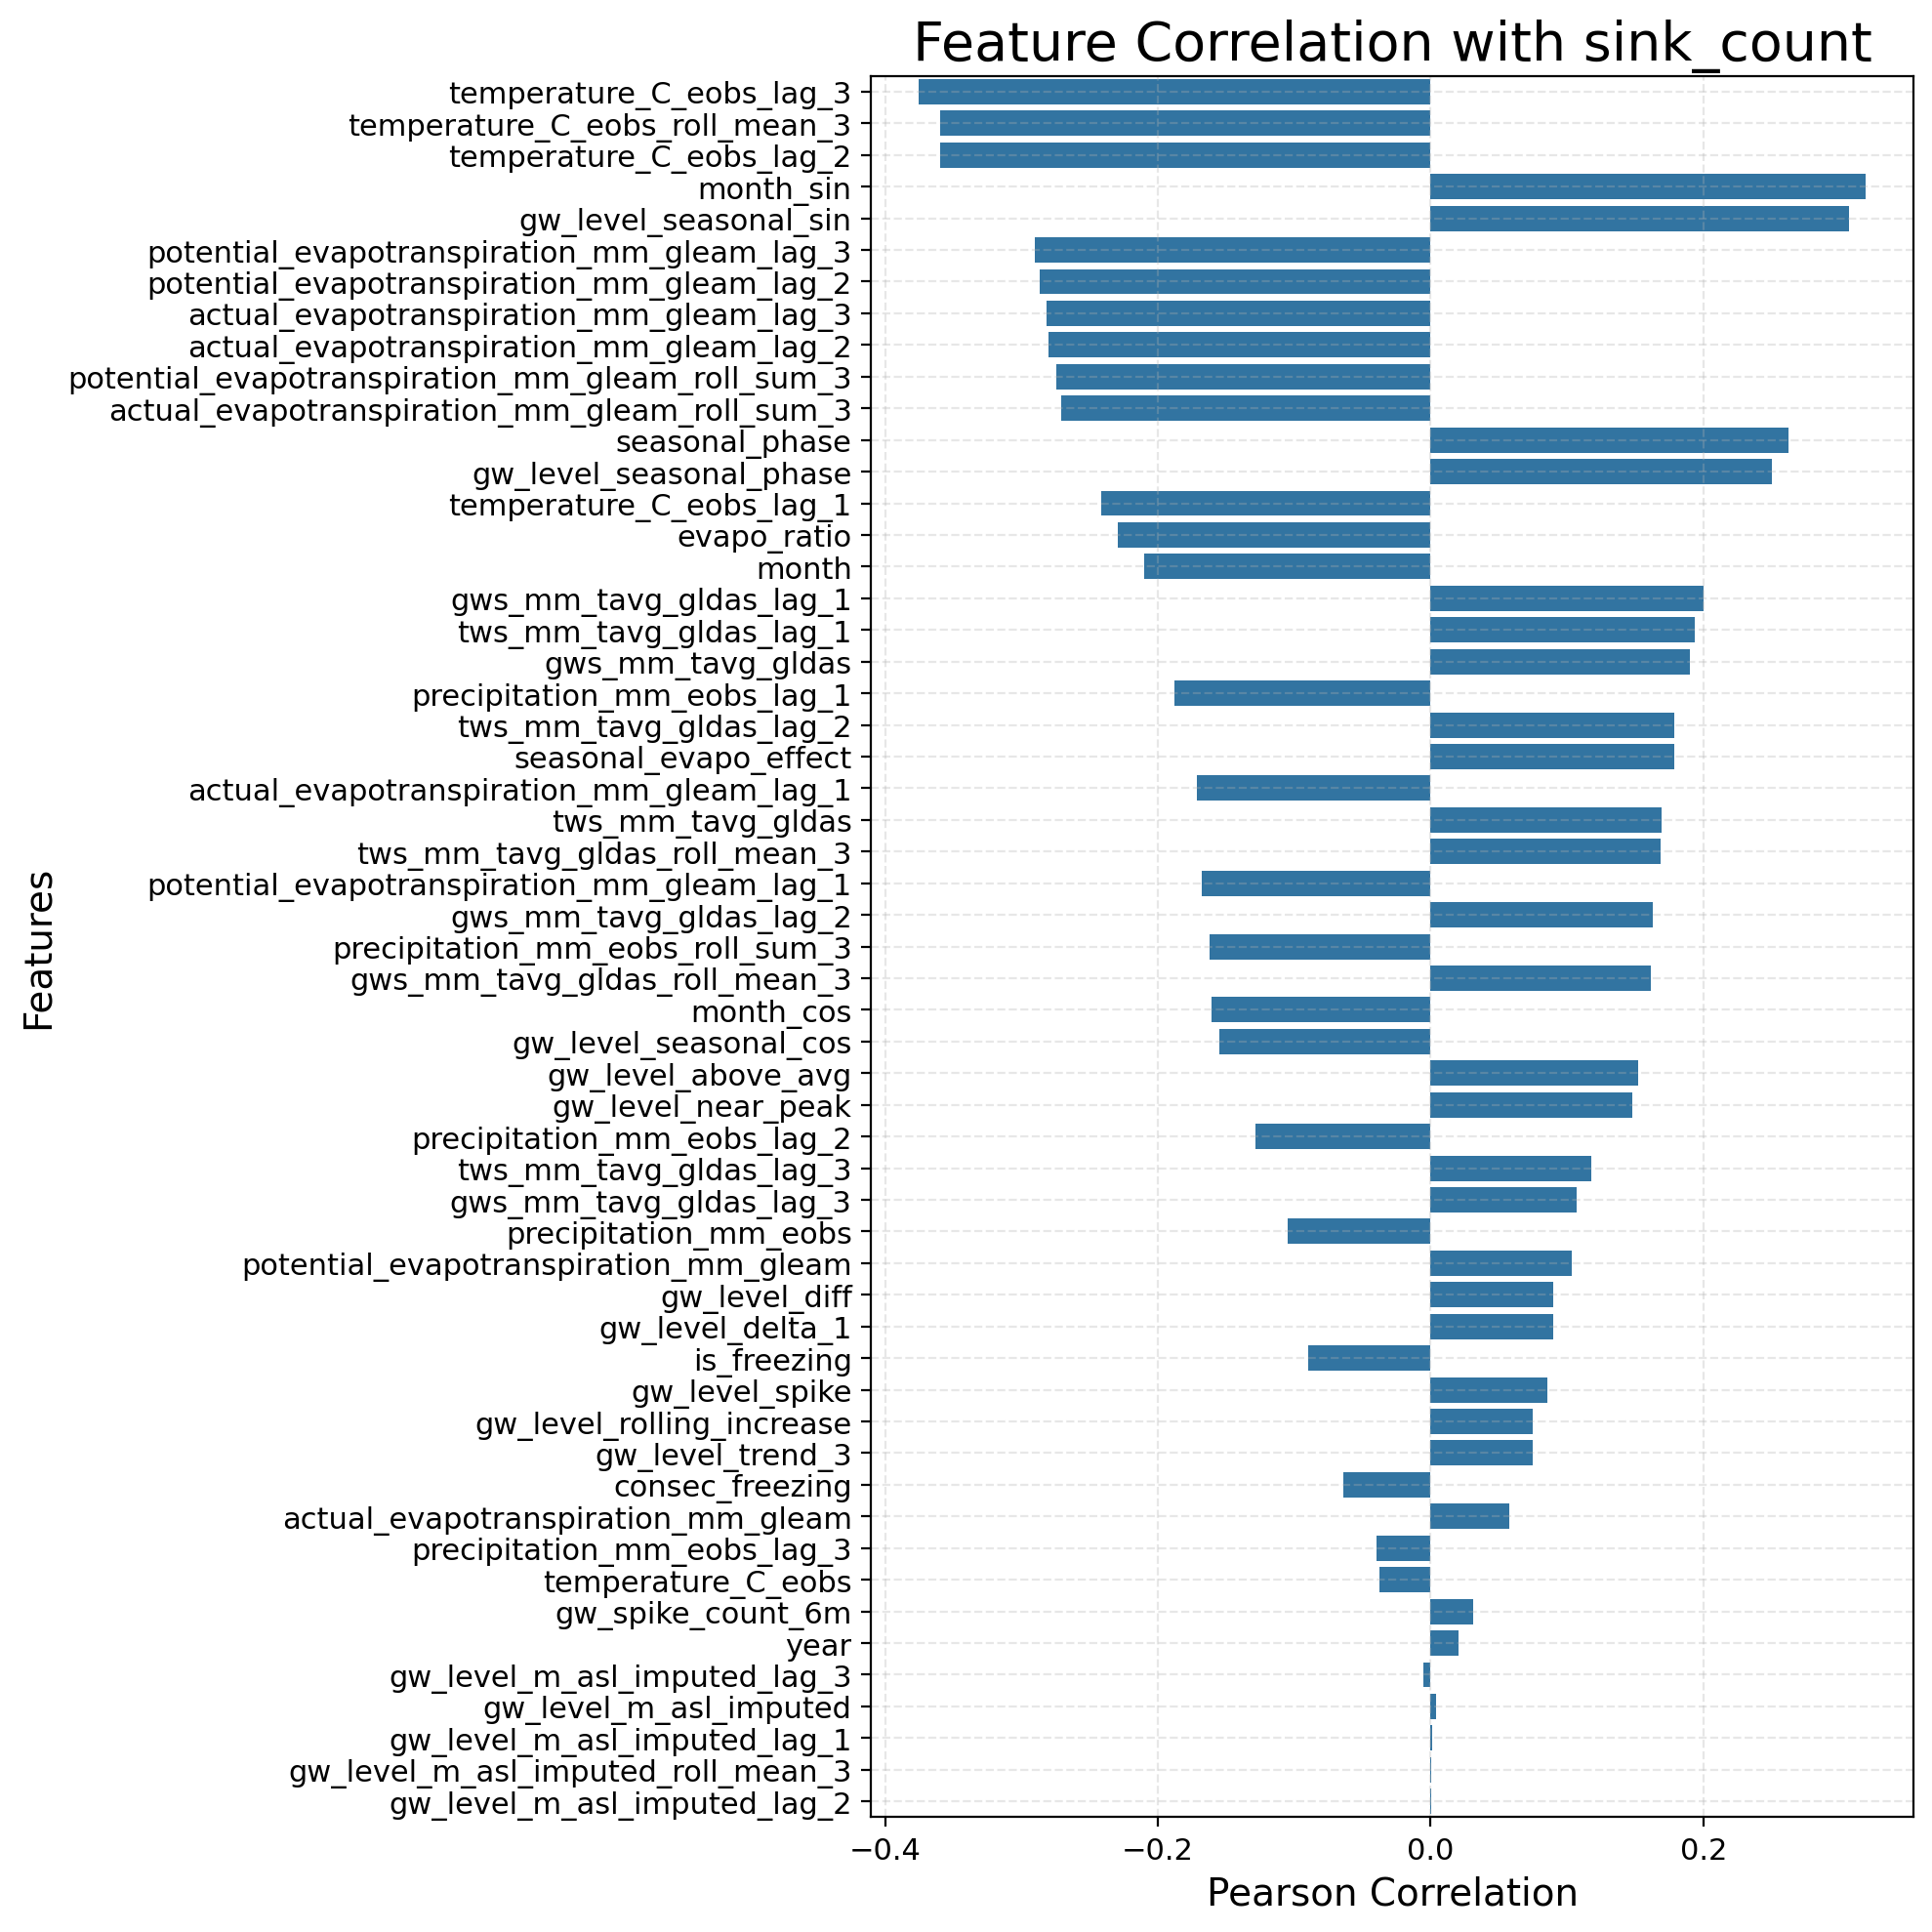

In [9]:
# ---- 1. Select numeric features only ----
# Exclude identifiers and non-numeric fields
numeric_df = df_work.select_dtypes(include=[np.number])

# ---- 2. Compute correlations ----
correlation_matrix = numeric_df.corr()

# ---- 3. Extract correlation with target ----
target_correlations = correlation_matrix['sink_count'].drop('sink_count').sort_values(key=abs, ascending=False)

# ---- 4. Plot bar chart ----
plt.figure(figsize=(10, 10))
sns.barplot(x=target_correlations.values, y=target_correlations.index)
plt.title('Feature Correlation with sink_count')
plt.xlabel('Pearson Correlation', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.grid(True)
plt.show()


In [10]:
feature_sets = {
    "Groundwater Features": [
        'gw_level_m_asl_imputed',
        # 'gw_level_m_asl_imputed_roll_mean_3',
        'gw_level_above_avg',
        # 'gw_level_rolling_increase',
        'gw_level_spike',
    ],
    "Climatic Features": [
        # 'temperature_C_eobs',
        'precipitation_mm_eobs',
        'actual_evapotranspiration_mm_gleam',
        'evapo_ratio',
        # 'temperature_C_eobs_lag_1',
        'precipitation_mm_eobs_lag_1',
        'actual_evapotranspiration_mm_gleam_lag_1',
        # 'temperature_C_eobs_lag_3',
        'precipitation_mm_eobs_lag_3',
        # 'actual_evapotranspiration_mm_gleam_lag_3',
    ],
    # Groundwater-Seasonal Combined Features
    "GS Combined Features": [
        'gw_level_m_asl_imputed',
        'gw_level_seasonal_phase',
        'gw_level_spike',
        'month_sin',
    ],
    # Climatic-Seasonal Combined Features
    "CS Combined Features": [
        'evapo_ratio',
        'temperature_C_eobs_roll_mean_3',
        'precipitation_mm_eobs_roll_sum_3',
        'seasonal_evapo_effect',
    ],
    "TWS Features": [
        'tws_mm_tavg_gldas',
        'tws_mm_tavg_gldas_roll_mean_3',
    ],
    "GWS Features": [
        'gws_mm_tavg_gldas',
        'gws_mm_tavg_gldas_roll_mean_3',
    ],
    "GWS-Seasonal-Features": [
        'gws_mm_tavg_gldas',
        'gws_mm_tavg_gldas_roll_mean_3',
        'month_sin',
    ],
    # Climatic-Groundwater-Seasonal Combined Features
    "CGS Combined Features": [
        'evapo_ratio',
        'temperature_C_eobs_roll_mean_3',
        'precipitation_mm_eobs_roll_sum_3',
        'actual_evapotranspiration_mm_gleam',
        # 'seasonal_evapo_effect',
        'gw_level_m_asl_imputed',
        'gw_level_seasonal_phase',
        # 'month_sin',
        # 'gws_mm_tavg_gldas',
        # 'gws_mm_tavg_gldas_roll_mean_3',
    ],
}


Variance Inflation Factor (VIF) is a key diagnostic metric used to detect multicollinearity among predictor variables in a regression or predictive modeling context. Multicollinearity occurs when two or more features are highly correlated, causing redundancy and instability in the model coefficients.

Why Multicollinearity Matters:

* Inflated standard errors, leading to less reliable coefficient estimates.

* Difficulty in interpreting individual feature effects.

* Reduced model generalizability and poorer predictive performance.

What VIF Measures:

* VIF quantifies how much the variance of a regression coefficient is inflated due to collinearity with other features.

* A VIF of 1 means no correlation; values above 1 indicate increasing correlation with other variables.

Why Select Feature Sets with VIF < 5?
* A common rule of thumb is to keep VIF values below 5 (some use 10 as a cutoff) to ensure multicollinearity is at an acceptable level.

* Features with VIF ≥ 5 are likely highly collinear with others, suggesting redundant information that can degrade model quality.

By selecting features with VIF < 5 in feature sets above:

* You reduce redundancy and noise.

* Improve model stability and interpretability.

* Help prevent overfitting by avoiding highly correlated predictors.

In [11]:
def calculate_vif(df):
    """
    Calculate Variance Inflation Factor (VIF) for each feature in a DataFrame.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)

    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
    return vif_data


def check_vif_for_feature_sets_all_wells(df, feature_sets):
    """
    Calculate VIF for each feature set across all wells, and return the average VIFs.
    """
    all_vif_records = []

    for well, group_df in df.groupby('well_no'):
        numeric_df = group_df.select_dtypes(include=[np.number]).dropna()
        for set_name, features in feature_sets.items():
            try:
                subset = numeric_df[features].dropna()
                if subset.shape[0] < 2:
                    continue  # Skip if not enough rows to compute VIF
                vif_df = calculate_vif(subset)
                vif_df["feature_set"] = set_name
                vif_df["well_no"] = well
                all_vif_records.append(vif_df)
            except KeyError as e:
                print(f"❌ Missing columns in feature set '{set_name}' for well '{well}': {e}")
            except Exception as e:
                print(f"⚠️ Error computing VIF for well '{well}' and feature set '{set_name}': {e}")

    if all_vif_records:
        full_vif_df = pd.concat(all_vif_records, ignore_index=True)

        # Average VIFs across wells
        avg_vif_df = (
            full_vif_df
            .groupby(['feature_set', 'feature'], as_index=False)
            .agg(avg_vif=('VIF', 'mean'), std_vif=('VIF', 'std'), count=('VIF', 'count'))
        )
        return avg_vif_df, full_vif_df
    else:
        return pd.DataFrame(columns=["feature_set", "feature", "avg_vif", "std_vif", "count"]), pd.DataFrame()

# Example usage:
if __name__ == "__main__":
    # Run VIF analysis across all wells
    avg_vif_df, all_vif_df = check_vif_for_feature_sets_all_wells(df_work, feature_sets)

    # Save to CSV
    avg_vif_df.to_csv('/content/vif_for_risk_assesment_features.csv', index=False)
    # all_vif_df.to_csv("all_vif_by_well.csv", index=False)

    # Show final result
    # print("\n📊 Average VIF Across All Wells:")
    print(avg_vif_df)

              feature_set                                   feature   avg_vif  \
0   CGS Combined Features        actual_evapotranspiration_mm_gleam  1.673209   
1   CGS Combined Features                               evapo_ratio  1.483002   
2   CGS Combined Features                    gw_level_m_asl_imputed  1.546637   
3   CGS Combined Features                   gw_level_seasonal_phase  2.690796   
4   CGS Combined Features          precipitation_mm_eobs_roll_sum_3  1.447950   
5   CGS Combined Features            temperature_C_eobs_roll_mean_3  3.627433   
6    CS Combined Features                               evapo_ratio  1.050788   
7    CS Combined Features          precipitation_mm_eobs_roll_sum_3  1.287129   
8    CS Combined Features                     seasonal_evapo_effect  1.384567   
9    CS Combined Features            temperature_C_eobs_roll_mean_3  1.640649   
10      Climatic Features        actual_evapotranspiration_mm_gleam  3.816019   
11      Climatic Features  a

## Categorical ML modeling

This modeling pipeline is designed to predict sinkhole risk levels (binary classification: Low risk vs High risk) based on a rich set of engineered features from groundwater and environmental data, evaluated across multiple wells. The key components and their purposes are as follows:

1. Data Preparation and Feature Engineering per Well
The dataset is grouped by individual wells (well_no) to respect spatial heterogeneity and local groundwater dynamics.

Time-dependent features such as groundwater level differences, rolling cumulative increases, and spikes are computed for each well in temporal order, ensuring causal relationships and avoiding data leakage.

Labels are mapped to a binary risk classification for clear decision boundaries.

2. Cross-Validation with Stratified Splits
Stratified K-Fold cross-validation ensures that each fold maintains the proportion of Low and High risk samples, improving the robustness and fairness of performance evaluation.

Splitting is performed per well dataset to handle class imbalance and temporal dependencies carefully.

3. Handling Class Imbalance with SMOTE and SMOTETomek
The combination of SMOTE (Synthetic Minority Oversampling Technique) and Tomek links addresses imbalance by generating synthetic minority class samples and cleaning ambiguous borderline cases.

The number of neighbors k for SMOTE is dynamically set to adapt to the training subset size, increasing stability in minority class generation.

4. Model Choice: Random Forest Classifier
A Random Forest model is employed with balanced class weights, controlling for imbalance and capturing complex nonlinear interactions between features.

Parameters such as number of estimators, tree depth, and leaf size are chosen to balance model complexity and overfitting risk.

5. Pipeline for Encoding and Prediction
A custom SimpleEncoder transforms categorical variables into numeric labels consistently across training and testing sets.

The pipeline ensures proper preprocessing and modeling steps are integrated and reproducible.

6. Performance Metrics and Reporting
Accuracy, ROC AUC, precision, recall, and F1 scores are computed per well and aggregated across all wells, giving granular and overall insight.

Confusion matrices (normalized by true class counts) are plotted to visualize classification errors across feature sets.

Multiple feature sets are evaluated systematically, allowing comparison of predictive power and robustness.

In [12]:
"""
End-to-end, time-aware classification & evaluation per well with SHAP saving & plots.

- Train/Test split by time: the FOUR NEWEST calendar years per well are held out for TESTING
- TimeSeriesSplit CV on the remaining (older) training period
- SMOTETomek imbalance handling (applied on final training fit; safe k auto-chosen)
- Optional GridSearchCV (inner CV is TimeSeriesSplit)
- Per-well & overall metrics
- Captures best hyperparameter set per well and includes it in outputs
- NEW: Saves SHAP arrays per (feature set, well) and aggregated per feature set
- NEW: Function to plot SHAP beeswarm per feature set in a grid with two subplots per row

Notes:
- Expects:
    * df_work: a DataFrame with columns:
        - 'well_no'   (group key)
        - 'year_month' (datetime-like; we coerce if needed)
        - 'risk_level' in {'Low risk', 'High risk'}
        - feature columns used in feature_sets
    * feature_sets: dict {name: list_of_feature_columns}

Outputs written to disk:
- general_summary.csv
- per_well_accuracy.csv
- per_well_results__{feature_set}.csv
- best_config_per_well.csv
- shap_values/{feature_set}/shap_well_{well}.npz  (per-well SHAP dump)
- shap_values/{feature_set}__AGGREGATED.npz       (aggregated across wells)
- shap_beeswarms_grid.png                         (grid of beeswarm plots)

Usage (example at bottom):
    results = evaluate_feature_sets(df_work, feature_sets)
    plot_beeswarms_for_feature_sets(results["shap_aggregated"], max_display=15,
                                    save_path="shap_beeswarms_grid.png")
"""

from __future__ import annotations
import os
import json
import logging
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from pandas.api.types import is_datetime64_any_dtype

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# -------------------- High-level toggles --------------------
USE_GRIDSEARCH = True     # <--- flip this to True to run GridSearchCV
N_JOBS = -1               # parallel jobs for GridSearchCV
VERBOSE = 1               # verbosity for GridSearchCV output

# Default RF hyperparameters (used when USE_GRIDSEARCH=False)
DEFAULT_RF_PARAMS = dict(
    n_estimators=200,
    max_depth=30,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=43
)

# Search space (used when USE_GRIDSEARCH=True)
# Exact union of the 14 configurations selected in the successful
# original 36-candidate run across all 56 well × feature-set searches.
# Relative candidate order is preserved from the original grid.
PARAM_GRID = [
    {
        'model__n_estimators': [200],
        'model__max_depth': [20],
        'model__min_samples_leaf': [2],
        'model__class_weight': ['balanced_subsample'],
    },
    {
        'model__n_estimators': [400],
        'model__max_depth': [20],
        'model__min_samples_leaf': [2],
        'model__class_weight': ['balanced_subsample'],
    },
    {
        'model__n_estimators': [200],
        'model__max_depth': [20],
        'model__min_samples_leaf': [3],
        'model__class_weight': ['balanced_subsample'],
    },
    {
        'model__n_estimators': [400],
        'model__max_depth': [20],
        'model__min_samples_leaf': [3],
        'model__class_weight': ['balanced_subsample'],
    },
    {
        'model__n_estimators': [200],
        'model__max_depth': [20],
        'model__min_samples_leaf': [5],
        'model__class_weight': ['balanced_subsample'],
    },
    {
        'model__n_estimators': [400],
        'model__max_depth': [20],
        'model__min_samples_leaf': [5],
        'model__class_weight': ['balanced_subsample'],
    },
    {
        'model__n_estimators': [200],
        'model__max_depth': [20],
        'model__min_samples_leaf': [3],
        'model__class_weight': [{0: 1, 1: 4}],
    },
    {
        'model__n_estimators': [400],
        'model__max_depth': [20],
        'model__min_samples_leaf': [3],
        'model__class_weight': [{0: 1, 1: 4}],
    },
    {
        'model__n_estimators': [200],
        'model__max_depth': [20],
        'model__min_samples_leaf': [5],
        'model__class_weight': [{0: 1, 1: 4}],
    },
    {
        'model__n_estimators': [400],
        'model__max_depth': [20],
        'model__min_samples_leaf': [5],
        'model__class_weight': [{0: 1, 1: 4}],
    },
    {
        'model__n_estimators': [200],
        'model__max_depth': [20],
        'model__min_samples_leaf': [2],
        'model__class_weight': [{0: 1, 1: 6}],
    },
    {
        'model__n_estimators': [400],
        'model__max_depth': [20],
        'model__min_samples_leaf': [2],
        'model__class_weight': [{0: 1, 1: 6}],
    },
    {
        'model__n_estimators': [200],
        'model__max_depth': [20],
        'model__min_samples_leaf': [5],
        'model__class_weight': [{0: 1, 1: 6}],
    },
    {
        'model__n_estimators': [400],
        'model__max_depth': [20],
        'model__min_samples_leaf': [5],
        'model__class_weight': [{0: 1, 1: 6}],
    },
]

# Cross-validation/config
random_state = 43
n_splits = 5  # desired inner CV splits (will be clamped if data is small)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)


# -------------------- Simple encoder --------------------
class SimpleEncoder(BaseEstimator, TransformerMixin):
    """Label-encodes object/category columns and leaves numeric columns as-is.

    Robust to unseen categories at transform time by mapping them to '__UNK__'.
    """
    def __init__(self):
        self.encoders = {}
        self.categorical_cols_ = None

    def fit(self, X, y=None):
        X = X.copy()
        self.categorical_cols_ = [
            c for c in X.columns
            if X[c].dtype == 'object' or str(X[c].dtype).startswith('category')
        ]
        for col in self.categorical_cols_:
            le = LabelEncoder()
            vals = X[col].astype(str).fillna("")
            uniques = pd.unique(vals)
            # include an explicit unknown bucket for robustness
            classes = np.concatenate([uniques, np.array(['__UNK__'])])
            le.fit(classes)
            self.encoders[col] = le
        return self

    def transform(self, X):
        X = X.copy()
        for col, le in self.encoders.items():
            vals = X[col].astype(str).fillna("")
            mask_unseen = ~np.isin(vals, le.classes_)
            if np.any(mask_unseen):
                vals.loc[mask_unseen] = '__UNK__'
            X[col] = le.transform(vals)
        return X


# -------------------- Utilities --------------------

def ensure_datetime(series):
    """
    Coerce to datetime64[ns].
    - If dtype is Period (e.g., period[M]), convert to the START of the period.
    """
    s = series if isinstance(series, pd.Series) else pd.Series(series)
    dtype = s.dtype

    # Period dtype -> convert to timestamp at the start of the period
    try:
        if isinstance(dtype, pd.PeriodDtype):
            return s.dt.to_timestamp(how="start")
    except Exception:
        pass

    # Datetime-like already? normalize via to_datetime
    if is_datetime64_any_dtype(dtype):
        return pd.to_datetime(s, errors="coerce")

    # Fallback: parse strings/ints/etc.
    return pd.to_datetime(s, errors="coerce")


def safe_roc_auc(y_true, y_proba):
    """ROC AUC only defined if both classes present; otherwise returns NaN."""
    try:
        if y_proba is not None and len(y_proba) == len(y_true):
            return roc_auc_score(y_true, y_proba)
        return np.nan
    except Exception:
        return np.nan


def compute_adaptive_k(y):
    """Choose a safe SMOTE k_neighbors from y."""
    class_counts = Counter(y)
    n_min = min(class_counts.values())
    # SMOTE requires at least k+1 minority samples; cap at 5
    k = max(1, min(5, n_min - 1))
    # If not enough minority samples to SMOTE (n_min < 2), return None to skip SMOTE
    return k if n_min >= 2 else None


def make_timeseries_inner_cv(n_samples, desired_splits=5):
    """
    Create a TimeSeriesSplit with a valid number of splits for n_samples.
    TimeSeriesSplit requires n_splits >= 2 and < n_samples.
    """
    if n_samples <= 3:
        return None
    n_splits_valid = min(desired_splits, max(2, n_samples - 1))
    if n_splits_valid >= n_samples:
        return None
    return TimeSeriesSplit(n_splits=n_splits_valid)


def _compute_tree_shap(model: RandomForestClassifier, X_enc: pd.DataFrame):
    """Compute SHAP values for a fitted tree model on encoded data.

    Ensures a 2D shape (n_samples, n_features) for SHAP values, picking the
    positive class when multi-class is present, or reducing extra dims.

    Returns (shap_values, base_values):
        - shap_values: np.ndarray [n_samples, n_features] for the positive class (1)
        - base_values: np.ndarray [n_samples] expected value replicated per sample
    """
    if X_enc is None or X_enc.shape[0] == 0:
        return None, None
    expl = shap.TreeExplainer(model)
    sv_raw = expl.shap_values(X_enc)

    # Normalize to a 2D array (n_samples, n_features)
    if isinstance(sv_raw, list):
        # pick positive class if available
        sv = np.array(sv_raw[1 if len(sv_raw) > 1 else 0])
        base = expl.expected_value[1 if (hasattr(expl, 'expected_value') and isinstance(expl.expected_value, (list, tuple)) and len(expl.expected_value) > 1) else 0]
    else:
        sv = np.array(sv_raw)
        base = expl.expected_value if np.ndim(expl.expected_value) == 0 else np.array(expl.expected_value).ravel()[0]

    # If still 3D, try to squeeze the class dimension
    if sv.ndim == 3:
        # common cases: (n_samples, n_features, n_classes) or (n_classes, n_samples, n_features)
        if sv.shape[0] == X_enc.shape[0]:
            # (n_samples, n_features, n_classes)
            sv = sv[:, :, 1 if sv.shape[2] > 1 else 0]
        elif sv.shape[1] == X_enc.shape[0]:
            # (n_classes, n_samples, n_features)
            sv = sv[1 if sv.shape[0] > 1 else 0, :, :]
        else:
            # fallback: average over the smallest axis (assumed class axis)
            class_axis = int(np.argmin([abs(d - X_enc.shape[0]) for d in sv.shape]))
            sv = np.take(sv, indices=0, axis=class_axis)

    # If 1D (single feature), make it 2D
    if sv.ndim == 1:
        sv = sv.reshape(-1, 1)

    base_vals = np.full(X_enc.shape[0], fill_value=float(base))
    return sv, base_vals


# -------------------- Core classification (per well; time-aware) --------------------

def run_classification(
    df: pd.DataFrame,
    label_col: str,
    features: list[str],
    time_col: str = 'year_month',
    use_gridsearch: bool = USE_GRIDSEARCH,
    param_grid: dict | None = PARAM_GRID,
    default_rf_params: dict | None = DEFAULT_RF_PARAMS
):
    """
    Time-aware training/evaluation:
      - TEST = rows in the two newest calendar years per well (by time_col).
      - TRAIN = all earlier rows.
      - Inner CV = TimeSeriesSplit on TRAIN only (for GridSearch if enabled).
      - Final pipeline: [encoder -> SMOTETomek(if feasible) -> RF] fit on TRAIN; evaluate on TEST.

    Returns:
        y_true_test, y_pred_test, y_proba_test, selected_features,
        X_test_enc (DataFrame), shap_values (np.ndarray), base_values (np.ndarray), best_params_overall
    """
    y_true_all, y_pred_all, y_proba_all = [], [], []
    selected_features = None
    X_test_enc = None
    shap_values = None
    base_values = None
    best_params_overall = None

    # Filter rows having all required cols and valid time
    needed = list(set(features + [label_col, time_col]))
    df_filtered = df.dropna(subset=[c for c in needed if c in df.columns]).copy()
    if df_filtered.empty:
        return y_true_all, y_pred_all, y_proba_all, selected_features, X_test_enc, shap_values, base_values, best_params_overall

    # Coerce time; drop NaT
    df_filtered[time_col] = ensure_datetime(df_filtered[time_col])
    df_filtered = df_filtered.dropna(subset=[time_col])
    if df_filtered.empty:
        return y_true_all, y_pred_all, y_proba_all, selected_features, X_test_enc, shap_values, base_values, best_params_overall

    # Sort by time
    df_filtered = df_filtered.sort_values(time_col).reset_index(drop=True)

    # Binary labels
    if df_filtered[label_col].nunique() < 2:
        return y_true_all, y_pred_all, y_proba_all, selected_features, X_test_enc, shap_values, base_values, best_params_overall

    # Train/Test by **four newest years**
    years = df_filtered[time_col].dt.year.dropna().astype(int)
    uniq_years_sorted = np.sort(years.unique())
    if len(uniq_years_sorted) == 0:
        return y_true_all, y_pred_all, y_proba_all, selected_features, X_test_enc, shap_values, base_values, best_params_overall

    test_years = set(uniq_years_sorted[-4:])  # <-- Four newest years
    is_test = years.isin(test_years)
    df_train = df_filtered.loc[~is_test].copy()
    df_test  = df_filtered.loc[is_test].copy()

    # Need at least 1 sample in test and at least 2 classes in train to proceed
    if df_test.empty or df_train.empty or df_train[label_col].nunique() < 2:
        return y_true_all, y_pred_all, y_proba_all, selected_features, X_test_enc, shap_values, base_values, best_params_overall

    X_train = df_train[features].reset_index(drop=True)
    y_train = df_train[label_col].reset_index(drop=True)
    X_test  = df_test[features].reset_index(drop=True)
    y_test  = df_test[label_col].reset_index(drop=True)

    # -------------------- Feature selection (skipped) --------------------
    # With <=5 features per set, we keep all features as-is.
    selected_features = list(X_train.columns)

    # -------------------- Hyperparameters (inner CV on TRAIN) --------------------
    if use_gridsearch:
        inner_cv = make_timeseries_inner_cv(n_samples=len(X_train), desired_splits=n_splits)
        if inner_cv is None:
            logger.info("GridSearch requested but training set is too small for TimeSeriesSplit; using defaults.")
            rf_params = dict(default_rf_params)
        else:
            gs_pipe = Pipeline([
                ('encoder', SimpleEncoder()),
                ('model', RandomForestClassifier(random_state=random_state))
            ])
            grid = GridSearchCV(
                gs_pipe, param_grid=param_grid, cv=inner_cv,
                scoring='roc_auc', n_jobs=N_JOBS, verbose=VERBOSE
            )
            grid.fit(X_train[selected_features], y_train)
            best_params = grid.best_params_
            rf_params = {k.split("model__", 1)[1]: v for k, v in best_params.items()}
            rf_params['random_state'] = random_state
            best_params_overall = dict(rf_params)
    else:
        rf_params = dict(default_rf_params)
        best_params_overall = dict(rf_params)

    # -------------------- Final pipeline with SMOTETomek (fit on TRAIN only) --------------------
    k = compute_adaptive_k(y_train)
    if k is not None:
        sampler = SMOTETomek(smote=SMOTE(k_neighbors=k, random_state=random_state),
                             random_state=random_state)
        final_pipe = ImbPipeline([
            ('encoder', SimpleEncoder()),
            ('sampler', sampler),
            ('model', RandomForestClassifier(**rf_params))
        ])
    else:
        final_pipe = ImbPipeline([
            ('encoder', SimpleEncoder()),
            ('model', RandomForestClassifier(**rf_params))
        ])

    # Fit on TRAIN (selected features), predict TEST
    final_pipe.fit(X_train[selected_features], y_train)
    y_pred = final_pipe.predict(X_test[selected_features])
    y_proba = None
    if hasattr(final_pipe.named_steps['model'], "predict_proba"):
        y_proba = final_pipe.predict_proba(X_test[selected_features])[:, 1]

    # Collect outputs
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    if y_proba is not None:
        y_proba_all.extend(y_proba)

    # Prepare encoded TEST matrix for SHAP
    X_test_enc = final_pipe.named_steps['encoder'].transform(X_test[selected_features].copy())

    # Compute SHAP on TEST (positive class)
    shap_values, base_values = _compute_tree_shap(final_pipe.named_steps['model'], X_test_enc)

    return (
        y_true_all, y_pred_all, y_proba_all,
        selected_features, X_test_enc, shap_values, base_values,
        best_params_overall
    )


# -------------------- Evaluation across feature sets --------------------

def evaluate_feature_sets(df_work: pd.DataFrame, feature_sets: dict[str, list[str]], time_col: str = 'year_month'):
    """
    df_work: DataFrame with at least columns:
        - 'well_no' (grouping key)
        - 'year_month' (time column)
        - 'gw_level_m_asl_imputed' (for temporal features; optional)
        - 'risk_level' with values 'Low risk' / 'High risk'
        - plus all features referenced in `feature_sets`

    feature_sets: dict {name: list_of_feature_columns}

    Returns a dict with:
        - general_summary (DataFrame)
        - per_well_accuracy (DataFrame)
        - per_well_tables (dict[str, DataFrame])
        - confusion_matrices (list[(feature_set, np.array)])
        - best_config_per_well (DataFrame)
        - shap_aggregated (dict[str, dict])  # aggregated SHAP per feature set for plotting
    """
    per_well_tables = {}
    general_summary = []
    confusion_matrices = []
    per_well_accuracy_combined = []

    # NEW: track best configuration per well across all feature sets
    best_config_by_well = {}

    # SHAP collectors
    shap_collector = defaultdict(lambda: {"X_list": [], "SV_list": [], "BV_list": [], "feature_names": None})

    def _primary_score(roc_auc, acc):
        if roc_auc is not None and not np.isnan(roc_auc):
            return float(roc_auc), "ROC AUC"
        return float(acc) if acc is not None else np.nan, "Accuracy"

    def _is_better(candidate, current):
        cand_score, _ = _primary_score(candidate['roc_auc'], candidate['accuracy'])
        curr_score, _ = _primary_score(current['roc_auc'], current['accuracy'])
        if cand_score > curr_score + 1e-12:
            return True
        if abs(cand_score - curr_score) <= 1e-12:
            if candidate['accuracy'] > current['accuracy'] + 1e-12:
                return True
            if abs(candidate['accuracy'] - current['accuracy']) <= 1e-12:
                return candidate.get('n_samples', 0) > current.get('n_samples', 0)
        return False

    # Ensure risk label is present
    if 'risk_level' not in df_work.columns:
        raise ValueError("df_work must contain a 'risk_level' column with 'Low risk'/'High risk' values.")

    # Work on a copy with binary label prepared once
    df_work = df_work.copy()
    df_work['year_month'] = ensure_datetime(df_work[time_col])
    df_work = df_work.dropna(subset=['year_month'])
    df_work = df_work[df_work['risk_level'].isin(['Low risk', 'High risk'])].copy()
    if df_work.empty:
        logger.warning("No rows with valid 'year_month' and risk labels.")
        return {
            "general_summary": pd.DataFrame(),
            "per_well_accuracy": pd.DataFrame(),
            "per_well_tables": {},
            "confusion_matrices": [],
            "best_config_per_well": pd.DataFrame(),
            "shap_aggregated": {}
        }
    df_work['binary_label'] = df_work['risk_level'].map({'Low risk': 0, 'High risk': 1})

    os.makedirs("shap_values", exist_ok=True)

    for name, features in feature_sets.items():
        logger.info(f"\n>>> Evaluating feature set: {name}")
        all_true, all_preds, all_probas = [], [], []
        well_results = []

        # Validate features exist
        missing = [f for f in features if f not in df_work.columns]
        if missing:
            logger.warning(f"Skipping feature set '{name}': missing columns: {missing}")
            continue

        # Prepare per-feature-set SHAP directory
        per_set_dir = os.path.join("shap_values", name)
        os.makedirs(per_set_dir, exist_ok=True)

        for well_id, df_well in df_work.groupby("well_no"):
            df_well = df_well.sort_values('year_month').copy()

            # --- Optional temporal/derived features from groundwater level ---
            if 'gw_level_m_asl_imputed' in df_well.columns:
                df_well['gw_level_diff'] = df_well['gw_level_m_asl_imputed'].diff()
                df_well['gw_level_rolling_increase'] = df_well['gw_level_diff'].rolling(window=3, min_periods=1).sum()
                df_well['gw_level_spike'] = (df_well['gw_level_diff'] > 0.5).astype(int)
                df_well['gw_spike_count_6m'] = df_well['gw_level_spike'].rolling(window=6, min_periods=1).sum()
            else:
                for col in ['gw_level_diff', 'gw_level_rolling_increase', 'gw_level_spike', 'gw_spike_count_6m']:
                    if col not in df_well.columns:
                        df_well[col] = np.nan

            # Need at least two classes overall in well
            if df_well['binary_label'].nunique() < 2:
                continue

            # --- Run time-aware classification for this well & feature set ---
            (
                y_true, y_pred, y_proba,
                selected_feats, X_test_enc, sv, bv,
                best_params
            ) = run_classification(
                df_well, 'binary_label', features, time_col='year_month'
            )

            if len(y_true) == 0:
                continue

            # Per-well test metrics
            acc = float(np.mean(np.array(y_true) == np.array(y_pred)))
            roc_auc = float(safe_roc_auc(y_true, y_proba))
            low_count = int(np.sum(np.array(y_true) == 0))
            high_count = int(np.sum(np.array(y_true) == 1))

            report_well = classification_report(
                y_true, y_pred,
                target_names=['Low risk', 'High risk'],
                output_dict=True, zero_division=0
            )
            prec_low = report_well['Low risk']['precision']
            rec_low = report_well['Low risk']['recall']
            f1_low = report_well['Low risk']['f1-score']
            prec_high = report_well['High risk']['precision']
            rec_high = report_well['High risk']['recall']
            f1_high = report_well['High risk']['f1-score']

            best_params_str = json.dumps(
                best_params if best_params is not None else DEFAULT_RF_PARAMS,
                sort_keys=True
            )

            # Store per-well results for this feature set
            well_results.append({
                'well_no': well_id,
                'accuracy': acc,
                'roc_auc': roc_auc,
                'low_risk_count': low_count,
                'high_risk_count': high_count,
                'precision_low': prec_low,
                'recall_low': rec_low,
                'f1_low': f1_low,
                'precision_high': prec_high,
                'recall_high': rec_high,
                'f1_high': f1_high,
                'best_params': best_params_str
            })

            # Combined table across feature sets
            per_well_accuracy_combined.append({
                'Feature Set': name,
                'well_no': well_id,
                'Accuracy': acc,
                'ROC AUC': roc_auc,
                'Low Risk Count': low_count,
                'High Risk Count': high_count,
                'Precision (Low)': prec_low,
                'Recall (Low)': rec_low,
                'F1 (Low)': f1_low,
                'Precision (High)': prec_high,
                'Recall (High)': rec_high,
                'F1 (High)': f1_high,
                'Best Params': best_params_str
            })

            # Track best configuration per well (NEW) using test metrics
            candidate = {
                'well_no': well_id,
                'feature_set': name,
                'accuracy': acc,
                'roc_auc': roc_auc,
                'score_value': _primary_score(roc_auc, acc)[0],
                'score_type': _primary_score(roc_auc, acc)[1],
                'best_params': best_params_str,
                'n_samples': int(len(y_true))
            }
            current = best_config_by_well.get(well_id)
            if current is None or _is_better(candidate, current):
                best_config_by_well[well_id] = candidate

            # Aggregate for overall (per feature set) confusion matrix and summary
            all_true.extend(y_true)
            all_preds.extend(y_pred)
            if y_proba is not None:
                all_probas.extend(y_proba)

            # -------------------- Save SHAP per (feature set, well) --------------------
            if sv is not None and X_test_enc is not None and selected_feats is not None and len(selected_feats) == X_test_enc.shape[1]:
                # Persist per-well dump
                np.savez_compressed(
                    os.path.join(per_set_dir, f"shap_well_{well_id}.npz"),
                    shap_values=sv,
                    base_values=bv if bv is not None else np.array([]),
                    data=X_test_enc.values,
                    feature_names=np.array(selected_feats)
                )
                # Collect for aggregation
                shap_collector[name]["X_list"].append(pd.DataFrame(X_test_enc.values, columns=selected_feats))
                shap_collector[name]["SV_list"].append(sv)
                shap_collector[name]["BV_list"].append(bv if bv is not None else np.array([]))
                shap_collector[name]["feature_names"] = selected_feats

        # Store per-well table for this feature set
        df_well_results = pd.DataFrame(well_results)
        per_well_tables[name] = df_well_results

        if not df_well_results.empty:
            out_path = f"per_well_results__{name}.csv"
            df_well_results.to_csv(out_path, index=False)
            logger.info(f"Saved per-well results for '{name}' -> {out_path}")

        # Confusion matrix (overall, on TEST across wells)
        if len(all_true) > 0:
            cm = confusion_matrix(all_true, all_preds, labels=[0, 1])
        else:
            cm = np.array([[0, 0], [0, 0]])
        confusion_matrices.append((name, cm))

        # Overall metrics (on TEST across wells)
        roc_auc_overall = safe_roc_auc(all_true, all_probas) if len(all_true) > 0 and len(all_probas) > 0 else np.nan
        low_count_overall = int(np.sum(np.array(all_true) == 0)) if len(all_true) > 0 else 0
        high_count_overall = int(np.sum(np.array(all_true) == 1)) if len(all_true) > 0 else 0

        if len(all_true) > 0:
            report = classification_report(
                all_true, all_preds, target_names=['Low risk', 'High risk'], output_dict=True, zero_division=0
            )
            accuracy_overall = report.get('accuracy', np.nan)
            prec_low = report['Low risk']['precision']
            rec_low = report['Low risk']['recall']
            f1_low = report['Low risk']['f1-score']
            prec_high = report['High risk']['precision']
            rec_high = report['High risk']['recall']
            f1_high = report['High risk']['f1-score']
        else:
            accuracy_overall = np.nan
            prec_low = rec_low = f1_low = np.nan
            prec_high = rec_high = f1_high = np.nan

        general_summary.append({
            'Feature Set': name,
            'Accuracy': accuracy_overall,
            'ROC AUC': roc_auc_overall,
            'Low Risk Count': low_count_overall,
            'High Risk Count': high_count_overall,
            'Precision (Low)': prec_low,
            'Recall (Low)': rec_low,
            'F1 (Low)': f1_low,
            'Precision (High)': prec_high,
            'Recall (High)': rec_high,
            'F1 (High)': f1_high,
        })

    # -------------------- Summary outputs --------------------
    df_general_summary = pd.DataFrame(general_summary)
    print("\n=== General Performance Summary (TEST across wells) ===")
    if not df_general_summary.empty:
        print(df_general_summary.round(3))
        df_general_summary.to_csv("general_summary.csv", index=False)
        logger.info("Saved -> general_summary.csv")
    else:
        print("(no results)")

    df_per_well_accuracy = pd.DataFrame(per_well_accuracy_combined)
    print("\n=== Accuracy Per Well (All Feature Sets) [TEST period only] ===")
    if not df_per_well_accuracy.empty:
        print(df_per_well_accuracy.round(3))
        df_per_well_accuracy.to_csv("per_well_accuracy.csv", index=False)
        logger.info("Saved -> per_well_accuracy.csv")
    else:
        print("(no results)")

    # Pivots (expanded to include the new metrics)
    if not df_per_well_accuracy.empty:
        pivot_metrics = [
            'Accuracy', 'ROC AUC',
            'Low Risk Count', 'High Risk Count',
            'Precision (Low)', 'Recall (Low)', 'F1 (Low)',
            'Precision (High)', 'Recall (High)', 'F1 (High)'
        ]
        for metric in pivot_metrics:
            if metric in df_per_well_accuracy.columns:
                pivot = df_per_well_accuracy.pivot(index='well_no', columns='Feature Set', values=metric)
                print(f"\n=== {metric} Per Well ===")
                print(pivot.round(3))

    # Confusion matrices
    for name, cm in confusion_matrices:
        print(f"\n=== Confusion Matrix for Feature Set: {name} (TEST across wells) ===")
        print(pd.DataFrame(cm, index=['True Low', 'True High'], columns=['Pred Low', 'Pred High']))

    # -------------------- NEW: Best configuration per well --------------------
    df_best_config = pd.DataFrame.from_dict(best_config_by_well, orient='index')
    df_best_config = df_best_config.sort_values('well_no').reset_index(drop=True)

    print("\n=== Best Performing Configuration Per Well (on TEST) ===")
    if not df_best_config.empty:
        display_cols = ['well_no', 'feature_set', 'score_type', 'score_value', 'accuracy', 'roc_auc', 'n_samples', 'best_params']
        print(df_best_config[display_cols].round(3))
        df_best_config.to_csv("best_config_per_well.csv", index=False)
        logger.info("Saved -> best_config_per_well.csv")
    else:
        print("(no results)")

    # -------------------- Aggregate & persist SHAP per feature set --------------------
    shap_aggregated = {}
    for fs_name, parts in shap_collector.items():

        X_list: list[pd.DataFrame] = parts["X_list"]
        SV_list: list[np.ndarray] = parts["SV_list"]
        BV_list: list[np.ndarray] = parts["BV_list"]
        if len(X_list) == 0 or len(SV_list) == 0:
            continue

        # Build a stable union of feature names preserving first-seen order
        union_cols = []
        seen = set()
        for X_df in X_list:
            for col in X_df.columns:
                if col not in seen:
                    union_cols.append(col)
                    seen.add(col)

        # Align each (X_df, SV) to the union by padding with zeros for missing features
        aligned_X = []
        aligned_SV = []
        aligned_BV = []
        for X_df, SV, BV in zip(X_list, SV_list, BV_list if len(BV_list) == len(SV_list) else [None]*len(SV_list)):
            # Coerce SV to 2D (n_samples, n_features_this_well)
            SV = np.asarray(SV)
            if SV.ndim == 3:
                if SV.shape[0] == X_df.shape[0]:
                    SV = SV[:, :, 1 if SV.shape[2] > 1 else 0]
                elif SV.shape[1] == X_df.shape[0]:
                    SV = SV[1 if SV.shape[0] > 1 else 0, :, :]
                else:
                    SV = SV.mean(axis=-1)
            elif SV.ndim == 1:
                SV = SV.reshape(-1, 1)

            # Reindex features to the union
            Xi = X_df.reindex(columns=union_cols, fill_value=np.nan)
            aligned_X.append(Xi)

            # Map SHAP columns (order == X_df.columns) into union matrix
            sv_pad = np.zeros((SV.shape[0], len(union_cols)), dtype=float)
            col_idx_map = {c: i for i, c in enumerate(union_cols)}
            for j, c in enumerate(X_df.columns):
                sv_pad[:, col_idx_map[c]] = SV[:, j]
            aligned_SV.append(sv_pad)

            if BV is not None and np.size(BV) > 0:
                aligned_BV.append(np.asarray(BV).ravel())
            else:
                aligned_BV.append(np.zeros(SV.shape[0]))

        X_concat = pd.concat(aligned_X, axis=0, ignore_index=True)
        SV_concat = np.vstack(aligned_SV)
        BV_concat = np.concatenate(aligned_BV)

        # Save aggregated dump
        out_npz = os.path.join("shap_values", f"{fs_name}__AGGREGATED.npz")
        np.savez_compressed(out_npz,
                            shap_values=SV_concat,
                            base_values=BV_concat,
                            data=X_concat.values,
                            feature_names=np.array(union_cols))
        logger.info(f"Saved aggregated SHAP -> {out_npz}")

        # Prepare Explanation for plotting API
        shap_expl = shap.Explanation(
            values=SV_concat,
            base_values=BV_concat,
            data=X_concat.values,
            feature_names=union_cols
        )
        shap_aggregated[fs_name] = {
            "explanation": shap_expl,
            "X_df": X_concat,
            "feature_names": union_cols
        }

    return {
        "general_summary": df_general_summary,
        "per_well_accuracy": df_per_well_accuracy,  # includes per-class metrics
        "per_well_tables": per_well_tables,
        "confusion_matrices": confusion_matrices,
        "best_config_per_well": df_best_config,
        "shap_aggregated": shap_aggregated
    }

if __name__ == "__main__":
    # Example (uncomment and replace with your data):
    df_work['year_month'] = ensure_datetime(df_work['year_month'])
    results = evaluate_feature_sets(df_work, feature_sets)
    pass


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 

KeyboardInterrupt: 

In [ ]:
def plot_beeswarms_for_feature_sets(
    shap_agg: dict,
    selected_feature_sets: list[str] | None = None,  # choose which feature sets to plot (order respected)
    max_display: int = 15,
    save_path: str | None = "shap_beeswarms_grid.jpeg",
    ncols: int = 2,
    use_constrained_layout: bool = True,
    colorbar_mode: str = "last",           # {"all","first","last","none"}

    # ---- spacing controls ----
    row_spacing: float | None = None,      # vertical space between rows (hspace)
    col_spacing: float | None = None,      # horizontal space between columns (wspace)
    edge_pad_h: float | None = None,       # top/bottom padding around the grid (inches; CL only)
    edge_pad_w: float | None = None,       # left/right padding around the grid (inches; CL only)

    *,
    # ---- fonts & sizing ----
    font_scale: float = 1.0,               # multiply all sizes below
    title_size: int = 12,                  # subplot title font size (before scaling)
    title_pad: float = 6.0,                # distance from title to axes, in points
    tick_size: int = 14,                   # x-axis tick labels
    panel_label_size: int = 16,            # "(a)" panel letters
    cb_tick_size: int | None = None,       # colorbar ticks (defaults to tick_size if None)
    cb_label_size: int | None = None,      # colorbar label (defaults to title_size if None)

    # ---- x-axis controls ----
    x_label_text: str = "SHAP value (impact on model output)",
    x_label_size: int | None = None,       # defaults to title_size if None (after scaling)
    x_label_pad: float = 8.0,              # distance from x label to axis, in points
    show_x_label: bool = True,             # toggle to show/hide the x-axis label
    xlim: tuple[float, float] | None = (-1.0, 1.0),  # fix x-axis; set to None to auto

    # ---- aspect / page-shape controls (NEW) ----
    target_aspect: float | None = 0.707,   # ensure width/height >= 0.707 (A4 portrait); set None to disable
    enforce_exact_aspect: bool = False,    # if True, width = height * target_aspect (exact A4-portrait shape)

    # ---- subplot titles & panel letters ----
    show_titles: bool = True,              # show feature set name as subplot title
    panel_label_offset: tuple[float, float] = (-0.40, 0.98),  # axes coords (x,y) for "(a)"

    # ---- feature-name (y-axis) toggle ----
    show_feature_names: bool = True,
    feature_name_size: int | None = None,  # y-axis labels; defaults to tick_size if None

    # ---- output ----
    dpi: int = 600,                        # save resolution
):
    """
    Plot a grid of SHAP beeswarm plots from a mapping:
      {feature_set_name: {"explanation": shap.Explanation, ...}, ...}

    Highlights
    ----------
    • Select a subset via `selected_feature_sets` (order respected).
    • Robust axes handling for 1×N, N×1, and 1×1 layouts.
    • Panel letters "(a)", "(b)", ... per subplot.
    • Font scaling and detailed spacing controls.
    • Per-subplot colorbar control via `colorbar_mode` = {"all","first","last","none"}.
    • Full control of the x-axis label.
    • `xlim` to fix the x-axis range (defaults to [-1, 1]).
    • NEW: `target_aspect` widens the figure toward A4 portrait (width/height ≈ 0.707).
            Set `enforce_exact_aspect=True` for an exact A4-portrait shape.
    """
    import math
    import warnings
    import numpy as np
    import matplotlib.pyplot as plt
    import shap

    # ---- basic checks ----
    if not shap_agg:
        warnings.warn("shap_agg is empty. Nothing to plot.")
        return

    if colorbar_mode not in {"all", "first", "last", "none"}:
        raise ValueError("colorbar_mode must be one of {'all','first','last','none'}")

    # ---- resolve font sizes with scaling ----
    title_size = title_size * font_scale
    tick_size = tick_size * font_scale
    panel_label_size = panel_label_size * font_scale
    cb_tick_size = tick_size if cb_tick_size is None else cb_tick_size * font_scale
    cb_label_size = title_size if cb_label_size is None else cb_label_size * font_scale
    feature_name_size = tick_size if feature_name_size is None else feature_name_size * font_scale
    x_label_size = title_size if x_label_size is None else x_label_size * font_scale

    # ---- choose which feature sets to plot (and in what order) ----
    if selected_feature_sets is None:
        fs_names = list(shap_agg.keys())
    else:
        fs_names = [name for name in selected_feature_sets if name in shap_agg]
        missing = [name for name in selected_feature_sets if name not in shap_agg]
        if missing:
            warnings.warn(f"Ignoring unknown feature sets: {missing}")

    if not fs_names:
        warnings.warn("No valid feature sets to plot after filtering. Nothing to do.")
        return

    # ---- grid geometry ----
    n = len(fs_names)
    ncols = max(1, int(ncols))
    nrows = int(math.ceil(n / ncols))

    # ---- base figure size heuristic ----
    fig_width = 14 if ncols == 2 else 10 + 3 * (ncols - 1)
    fig_height = max(4.8, 5.2 * nrows)

    # ---- widen toward A4 portrait if requested ----
    if target_aspect is not None and target_aspect > 0:
        current_aspect = fig_width / fig_height
        desired_width = fig_height * target_aspect
        if enforce_exact_aspect:
            fig_width = desired_width
        else:
            # Ensure at least the target aspect (only widens if currently too narrow)
            fig_width = max(fig_width, desired_width)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_width, fig_height),
        constrained_layout=use_constrained_layout,
    )

    # Normalize axes to a flat 1-D array (handles 1×N, N×1, 1×1)
    axes_flat = axes.ravel() if isinstance(axes, np.ndarray) else np.array([axes], dtype=object)
    orig_size = fig.get_size_inches().copy()  # remember intended size

    # ---- apply spacing preferences (constrained layout only) ----
    if use_constrained_layout:
        pads = {}
        if edge_pad_w is not None: pads["w_pad"] = edge_pad_w
        if edge_pad_h is not None: pads["h_pad"] = edge_pad_h
        if col_spacing is not None: pads["wspace"] = col_spacing
        if row_spacing is not None: pads["hspace"] = row_spacing
        if pads:
            try:
                fig.set_constrained_layout_pads(**pads)
            except Exception:
                pass

    # ---- helpers ----
    def _panel_tag(i: int) -> str:
        # (a), (b), ..., (z), (aa), (ab), ...
        letters = []
        k = i
        while True:
            k, rem = divmod(k, 26)
            letters.append(chr(97 + rem))
            if k == 0:
                break
            k -= 1
        return f"({''.join(reversed(letters))})"

    def _show_colorbar_for(idx: int) -> bool:
        return (
            colorbar_mode == "all"
            or (colorbar_mode == "first" and idx == 0)
            or (colorbar_mode == "last" and idx == n - 1)
        )

    # ---- plotting loop ----
    for idx, fs_name in enumerate(fs_names):
        ax = axes_flat[idx]
        plt.sca(ax)

        # Track axes before SHAP draw (to find any new colorbar axes)
        axes_before = set(map(id, fig.axes))

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            # Support older/newer SHAP signatures
            try:
                shap.plots.beeswarm(
                    shap_agg[fs_name]["explanation"],
                    max_display=max_display,
                    show=False,
                    color_bar=_show_colorbar_for(idx),
                )
            except TypeError:
                shap.plots.beeswarm(
                    shap_agg[fs_name]["explanation"],
                    max_display=max_display,
                    show=False,
                )

        # SHAP sometimes resizes the figure; undo that
        fig.set_size_inches(orig_size, forward=True)

        # ---- style axes ----
        ax.tick_params(axis="x", labelsize=tick_size)

        if xlim is not None:
            try:
                ax.set_xlim(xlim[0], xlim[1])
            except Exception:
                pass

        if show_x_label:
            try:
                ax.set_xlabel(x_label_text, fontsize=x_label_size, labelpad=x_label_pad)
            except Exception:
                ax.set_xlabel(x_label_text)
                try:
                    ax.xaxis.label.set_size(x_label_size)
                except Exception:
                    pass
        else:
            ax.set_xlabel("")

        ax.tick_params(axis="y", labelsize=feature_name_size, labelleft=show_feature_names)
        if not show_feature_names:
            ax.tick_params(axis="y", which="both", length=0)
            try:
                ax.set_yticklabels([])
            except Exception:
                pass

        if show_titles:
            ax.set_title(fs_name, fontsize=title_size, pad=title_pad)

        ax.text(
            panel_label_offset[0],
            panel_label_offset[1],
            _panel_tag(idx),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=panel_label_size,
            fontweight="bold",
        )

        # Style any new axes (e.g., colorbars)
        new_axes = [a for a in fig.axes if id(a) not in axes_before]
        for cb_ax in new_axes:
            if cb_ax is ax:
                continue
            try:
                cb_ax.tick_params(labelsize=cb_tick_size)
                if getattr(cb_ax.yaxis, "label", None):
                    cb_ax.yaxis.label.set_size(cb_label_size)
                if getattr(cb_ax.xaxis, "label", None):
                    cb_ax.xaxis.label.set_size(cb_label_size)
            except Exception:
                pass

    # ---- hide any unused axes ----
    for idx in range(n, nrows * ncols):
        axes_flat[idx].axis("off")

    # ---- layout & save ----
    if not use_constrained_layout:
        try:
            fig.tight_layout(rect=(0, 0, 1, 0.97))
        except Exception:
            pass
        fig.subplots_adjust(
            top=0.93,
            left=0.08,
            right=0.98,
            wspace=0.28 if col_spacing is None else col_spacing,
            hspace=0.34 if row_spacing is None else row_spacing,
        )

    if save_path:
        fig.canvas.draw_idle()
        if use_constrained_layout:
            fig.savefig(save_path, dpi=dpi)  # with CL, avoid bbox_inches
        else:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


In [ ]:
plot_beeswarms_for_feature_sets(
    results["shap_aggregated"],
    selected_feature_sets=["Groundwater Features", "Climatic Features", "GS Combined Features",  "CS Combined Features"],
    max_display=15,
    save_path="shap_beeswarms_sinkholes_1.jpeg",
    ncols=1,
    use_constrained_layout=True,
    colorbar_mode="all",
    # spacing
    row_spacing=0.2,
    edge_pad_h=0.1,
    edge_pad_w=0.5,
    # fonts & labels
    font_scale=1.15,         # bump everything
    title_size=16,           # subplot titles
    title_pad=16.0,
    tick_size=15,            # x-axis ticks
    feature_name_size=16,    # y-axis feature names
    panel_label_size=16,     # "(a)" labels
    cb_tick_size=15,         # colorbar tick labels
    cb_label_size=15,        # colorbar title
    x_label_text="SHAP value",
    x_label_size=16,
    show_titles=True,
    panel_label_offset=(-1.0, 0.98),
    show_feature_names=True
)

In [ ]:
plot_beeswarms_for_feature_sets(
    results["shap_aggregated"],
    selected_feature_sets=["TWS Features", "GWS Features", "GWS-Seasonal-Features",  "CGS Combined Features"],
    max_display=15,
    save_path="shap_beeswarms_sinkholes_2.jpeg",
    ncols=1,
    use_constrained_layout=True,
    colorbar_mode="all",
    # spacing
    row_spacing=0.2,
    edge_pad_h=0.1,
    edge_pad_w=2.0,
    # fonts & labels
    font_scale=1.15,         # bump everything
    title_size=16,           # subplot titles
    title_pad=16.0,
    tick_size=15,            # x-axis ticks
    feature_name_size=14,    # y-axis feature names
    panel_label_size=16,     # "(a)" labels
    cb_tick_size=15,         # colorbar tick labels
    cb_label_size=15,        # colorbar title
    x_label_text="SHAP value",
    x_label_size=16,
    show_titles=True,
    panel_label_offset=(-1.0, 0.98),
    show_feature_names=True
)

In [ ]:
per_well_df = results.get("per_well_accuracy", pd.DataFrame()).copy()

# Require the new per-class columns from the updated table
required_cols = [
    "Feature Set", "well_no",
    "Low Risk Count", "High Risk Count",
    "Recall (Low)", "Recall (High)"
]
missing = [c for c in required_cols if c not in per_well_df.columns]
if missing:
    raise ValueError(
        f"The per_well_accuracy table is missing required columns: {missing}. "
        "Make sure you ran the updated evaluate_feature_sets() that adds per-class metrics."
    )

# If there are duplicates (e.g., repeated runs), keep the best-per-well row
# Prefer ROC AUC when available; otherwise Accuracy
per_well_df["_primary_score"] = np.where(
    per_well_df["ROC AUC"].notna(), per_well_df["ROC AUC"], per_well_df["Accuracy"]
)
per_well_best = (
    per_well_df.sort_values(["Feature Set", "well_no", "_primary_score"], ascending=[True, True, False])
               .drop_duplicates(subset=["Feature Set", "well_no"], keep="first")
)

# Aggregate confusion matrices per Feature Set using recalls + true class counts
# Confusion matrix layout:
#               Pred Low   Pred High
# True Low          a           b
# True High         c           d
# With:
#   a = recall_low  * N_low
#   d = recall_high * N_high
#   b = N_low  - a
#   c = N_high - d
confusion_matrices_agg = []  # list of (feature_set, cm_2x2)

for feat_name, g in per_well_best.groupby("Feature Set"):
    cm_sum = np.zeros((2, 2), dtype=float)
    for _, r in g.iterrows():
        N0 = float(r["Low Risk Count"])
        N1 = float(r["High Risk Count"])
        rec0 = float(r["Recall (Low)"])
        rec1 = float(r["Recall (High)"])
        if np.isnan(N0) or np.isnan(N1) or np.isnan(rec0) or np.isnan(rec1):
            continue

        a = max(0.0, min(rec0 * N0, N0))
        d = max(0.0, min(rec1 * N1, N1))
        b = max(0.0, N0 - a)
        c = max(0.0, N1 - d)

        cm_sum += np.array([[a, b], [c, d]], dtype=float)

    confusion_matrices_agg.append((feat_name, cm_sum))

# -------------------- Plot confusion matrices (normalized) --------------------
# Font size controls
SUPTITLE_FS = 16
TITLE_FS = 18
LABEL_FS = 20
TICK_FS = 16
ANNOT_FS = 18
SUBPLOT_LETTER_FS = 18

mpl.rcParams.update({
    "axes.titlesize": TITLE_FS,
    "axes.labelsize": LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "figure.titlesize": SUPTITLE_FS,
})

n_sets = len(confusion_matrices_agg)
cols = 2
rows = math.ceil(n_sets / cols)
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows), constrained_layout=True)

# Handle the case of a single subplot (axes may not be an array)
axes_flat = np.ravel(axes) if isinstance(axes, np.ndarray) else np.array([axes])

for i, (ax, (name, cm_sum)) in enumerate(zip(axes_flat, confusion_matrices_agg)):
    # Normalize by row (true label)
    with np.errstate(invalid='ignore', divide='ignore'):
        row_sums = cm_sum.sum(axis=1, keepdims=True)
        cm_norm = cm_sum / row_sums
    cm_norm = np.nan_to_num(cm_norm)

    disp = ConfusionMatrixDisplay(cm_norm, display_labels=['Low risk', 'High risk'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=".2f")

    # --- remove gridlines (and optionally the box) ---
    ax.grid(False, which='both')

    # Remove per-subplot axis labels so we can use shared labels
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Title notes aggregation logic
    ax.set_title(f"{name}", fontsize=TITLE_FS)

    # Tick label size
    ax.tick_params(axis='both', labelsize=TICK_FS)

    # Resize annotation numbers inside cells
    if getattr(disp, "text_", None) is not None:
        for txt in np.ravel(disp.text_):
            txt.set_fontsize(ANNOT_FS)

    # Subplot letter
    subplot_letter = string.ascii_lowercase[i]
    ax.text(-0.14, 0.95, f"({subplot_letter})", transform=ax.transAxes,
            fontsize=SUBPLOT_LETTER_FS, fontweight='bold', va='top', ha='left')

# Remove any unused subplots
total_axes = rows * cols
for j in range(n_sets, total_axes):
    fig.delaxes(axes_flat[j])

# shared x/y labels
fig.supxlabel("Predicted label", fontsize=LABEL_FS)
fig.supylabel("True label", fontsize=LABEL_FS)

plt.savefig("confusion_matrices_normalized__best_params_aggregated.jpeg", dpi=600, bbox_inches='tight')
plt.show()

### Groundwater level effect on sinkhole formation

By displaying GW level peaks and sinkhole counts together, this visualization aims to:

* Investigate Temporal Coincidence:
Assess whether periods of high groundwater levels tend to coincide with increased sinkhole occurrences.

* Support Hypothesis on Causality:
Groundwater peaks may destabilize subsurface structures, potentially triggering sinkholes.

* Well-Specific Patterns:
Examining each well individually accounts for local hydrogeological differences and helps identify wells with strong GW level-sinkhole coupling.

In [ ]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import ticker
from collections import OrderedDict

# -------------------- CONFIG --------------------
# Print-ready sizing (A4 portrait) and larger fonts
A4_W_IN, A4_H_IN = 8, 12   # inches (approx A4 portrait)
DPI = 600                  # print quality

plt.rcParams.update({
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "axes.titlesize": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

# -------------------- INPUTS --------------------
# Expect these to exist:
# - df_work: DataFrame with columns ['well_no','year_month','gw_level_m_asl_imputed','sink_count', ('gw_level_near_peak' optional)]
# - threshold: numeric value for sinkhole risk threshold

# -------------------- PREP --------------------
wells   = sorted(df_work['well_no'].unique())
n_plots = len(wells)
if n_plots == 0:
    raise ValueError("No wells found to plot.")

# Figure with stacked subplots and shared x-axis
fig, axes = plt.subplots(n_plots, 1, figsize=(A4_W_IN, A4_H_IN), sharex=True)
if n_plots == 1:
    axes = [axes]

# Date formatting for the shared x-axis
locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

# Collect legend entries once, then show a single legend at the bottom
legend_pairs = []  # list of (handle, label)

# -------------------- PLOTTING --------------------
for idx, (ax1, well_id) in enumerate(zip(axes, wells)):
    df_well = (
        df_work.loc[df_work['well_no'] == well_id]
        .sort_values('year_month')
        .copy()
    )

    # LEFT axis: GW level time series (blue)
    h_gw = ax1.plot(
        df_well['year_month'],
        df_well['gw_level_m_asl_imputed'],
        linewidth=2.0, label='GW Level (m ASL)', color='tab:blue'
    )
    # Y padding (±10%)
    gw_min = df_well['gw_level_m_asl_imputed'].min()
    gw_max = df_well['gw_level_m_asl_imputed'].max()
    gw_rng = (gw_max - gw_min) if pd.notna(gw_max) and pd.notna(gw_min) else 1.0
    ax1.set_ylim(gw_min - 0.10 * gw_rng, gw_max + 0.10 * gw_rng)

    # Style left y-axis blue (no per-axes y-labels; figure-level label added later)
    ax1.tick_params(axis='y', colors='tab:blue')
    if 'left' in ax1.spines:
        ax1.spines['left'].set_color('tab:blue')
    ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

    # Highlight periods near GW peak (±30 days around each flagged center)
    spans_this_ax = 0
    if 'gw_level_near_peak' in df_well.columns:
        for _, row in df_well[df_well['gw_level_near_peak'] == 1].iterrows():
            center_date = pd.to_datetime(row['year_month'])
            h_span = ax1.axvspan(
                center_date - pd.Timedelta(days=30),
                center_date + pd.Timedelta(days=30),
                color='green', alpha=0.2,
                label=('Near GW Peak Window'
                       if spans_this_ax == 0 and not any(lab == 'Near GW Peak Window' for _, lab in legend_pairs)
                       else '')
            )
            spans_this_ax += 1
            if spans_this_ax == 1 and h_span.get_label():
                legend_pairs.append((h_span, 'Near GW Peak Window'))

    # RIGHT axis: Sinkhole counts as bars + risk threshold (red)
    ax2 = ax1.twinx()
    h_bar = ax2.bar(
        df_well['year_month'],
        df_well['sink_count'],
        width=20, alpha=0.8, label='Sinkhole Count', color='tab:red'
    )
    ax2.tick_params(axis='y', colors='tab:red')
    if 'right' in ax2.spines:
        ax2.spines['right'].set_color('tab:red')
    ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

    # Threshold line
    h_thr = ax2.axhline(
        threshold, linestyle='--', linewidth=1.5,
        label='Sinkhole Risk Threshold', color='black'
    )

    # --- Grids: horizontal only, driven by the sinkhole (right) axis ---
    ax1.grid(False)  # ensure no grid from left axis
    ax2.grid(axis='y', linestyle='--', alpha=0.6)  # horizontal only
    ax2.set_axisbelow(True)

    # Legend items (only once globally)
    if not any(lab == 'GW Level (m ASL)' for _, lab in legend_pairs):
        legend_pairs.append((h_gw[0], 'GW Level (m ASL)'))
    if not any(lab == 'Sinkhole Count' for _, lab in legend_pairs):
        legend_pairs.append((h_bar, 'Sinkhole Count'))
    if not any(lab == 'Sinkhole Risk Threshold' for _, lab in legend_pairs):
        legend_pairs.append((h_thr, 'Sinkhole Risk Threshold'))

    # Subplot cosmetics
    ax1.set_title(f"Well {well_id}", pad=6)
    ax1.margins(x=0.01)

    # Subplot label (a), (b), ...
    ax1.text(
        0.01, 1.02, f"({chr(97 + idx)})",
        transform=ax1.transAxes,
        fontsize=16, fontweight='bold', va='bottom', ha='left', clip_on=False
    )

    # Only bottom subplot shows x tick labels to save space
    if idx < n_plots - 1:
        ax1.tick_params(axis='x', which='both', labelbottom=False)

# -------------------- SHARED AXIS & LABELS --------------------
# Shared x-axis formatting on the bottom subplot
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(formatter)
axes[-1].set_xlabel("Date")

# ONE figure-wide y-label per side
fig.supylabel("GW Level (m ASL)", x=0.08, fontsize=16, color='tab:blue')
fig.text(0.96, 0.5, "Sinkhole Count", rotation=270,
         va='center', ha='right', fontsize=16, color='tab:red')

# -------------------- LEGEND (two rows) --------------------
unique = OrderedDict()
for h, lab in legend_pairs:
    if lab and lab not in unique:
        unique[lab] = h

# Reserve minimal space at bottom; more room for plots
fig.tight_layout(rect=(0.07, 0.08, 0.93, 1.00))

# Force a two-row legend by choosing columns = ceil(n_items / 2)
n_items = len(unique)
ncol = (n_items + 1) // 2  # integer ceil for 2 rows

fig.legend(
    list(unique.values()), list(unique.keys()),
    loc='lower center',
    ncol=ncol,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.0,
    bbox_to_anchor=(0.5, 0.035)
)

# -------------------- EXPORT --------------------
out_path = "gw_level_peaks_sinkhole.jpeg"
fig.savefig(out_path, bbox_inches='tight', pad_inches=0.3)
plt.show()

These scatter plots with linear trendlines illustrate the relationship between groundwater (GW) levels and sinkhole counts for individual wells. Each subplot shows how elevated GW levels tend to be associated with an increase in sinkhole occurrences, revealing a slight positive correlation.

While the correlation is generally modest, the trendlines and statistical metrics (R² and MAE) highlight that higher groundwater levels may contribute to increased sinkhole risk. These plots help visualize this relationship on a per-well basis, supporting the broader hypothesis that groundwater dynamics influence sinkhole formation.

In [ ]:
# Unique wells and configuration
wells = df_work['well_no'].dropna().unique()
plots_per_fig = 8
cols = 2
rows = math.ceil(plots_per_fig / cols)

# Split into batches of 8
for fig_start in range(0, len(wells), plots_per_fig):
    fig_wells = wells[fig_start:fig_start + plots_per_fig]
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
    axes = axes.flatten()

    for i, well in enumerate(fig_wells):
        ax = axes[i]
        sub_df = df_work[df_work['well_no'] == well].dropna(subset=['gw_level_m_asl_imputed', 'sink_count'])

        if len(sub_df) < 2:
            ax.set_visible(False)
            continue

        X = sub_df[['sink_count']].values
        y = sub_df['gw_level_m_asl_imputed'].values

        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)

        sns.scatterplot(ax=ax, data=sub_df, x='sink_count', y='gw_level_m_asl_imputed', label='Data')
        ax.plot(sub_df['sink_count'], y_pred, color='red', label='Trendline')

        # Custom legend entries for R² and MAE
        r2_label = f'R² = {r2:.2f}'
        mae_label = f'MAE = {mae:.2f}'
        dummy_r2 = Line2D([0], [0], color='white', label=r2_label)
        dummy_mae = Line2D([0], [0], color='white', label=mae_label)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            [*handles, dummy_r2, dummy_mae],
            [*labels, dummy_r2.get_label(), dummy_mae.get_label()],
            loc='lower right',
            fontsize=13,           # <-- bigger text
            markerscale=1.6,       # <-- bigger scatter dots in legend
            handlelength=2.5,
            frameon=True, fancybox=True
        )

        ax.set_title(f'{well}', fontsize=24)
        ax.set_xlabel('Sinkhole Count', fontsize=20)
        ax.set_ylabel('GW Level (m ASL)', fontsize=20)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig("gw_level_vs_peaks_r2_mae.jpeg", dpi=600)
    plt.show()